# 028 — Load and Plot SHAP Results

Load per-fold RF SHAP artefacts produced by `shap_train_fold.py` / `shap_aggregate.py` and
replicate all global plots: feature importance bar chart, per-fold heatmap, and beeswarm over all evaluated transcripts.

**Input directory** (set in the *Configuration* cell):  
`results/{expt}/features/shap_clustered/`

In [ ]:
# ── Imports + path setup ──────────────────────────────────────────────────────
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore")

# Make Arial available (msfonts/ is in workspace root)
msfonts_dir = Path("/mnt/cbib/LNClassifier/msfonts")
if msfonts_dir.exists():
    from matplotlib import font_manager
    for _fp in msfonts_dir.glob("*.ttf"):
        font_manager.fontManager.addfont(str(_fp))
    matplotlib.rcParams["font.family"] = "Arial"

matplotlib.rcParams["pdf.fonttype"] = 42  # TrueType fonts in PDF

# Make workflow utils importable
sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
print("Python:", sys.version.split()[0], " | shap:", shap.__version__)

Python: 3.12.12  | shap: 0.50.0


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Edit these parameters to change dataset / display options.

# Directory produced by shap_aggregate.py (contains fold1/, fold2/, … and CSVs)
SHAP_DIR: Path = Path(
    "/mnt/cbib/LNClassifier/paper/results"
    "/gencode.v47.common.cdhit.cv/features/shap_clustered"
)

# Number of cross-validation folds
N_FOLDS: int = 5

# Top-N features to show in importance / heatmap plots
TOP_N: int = 20

# Dataset label used in plot titles
DATASET_LABEL: str = "gencode.v47.common.cdhit.cv (clustered features)"

# Save figures to disk?  Set to True to write PDF + PNG alongside the CSV results.
SAVE_PLOTS: bool = True
FIGURES_DIR: Path = SHAP_DIR  # change to a different Path to redirect saved figures
DPI: int = 300

assert SHAP_DIR.exists(), f"SHAP_DIR not found: {SHAP_DIR}"
print(f"SHAP_DIR  : {SHAP_DIR}")
print(f"N_FOLDS   : {N_FOLDS}")
print(f"TOP_N     : {TOP_N}")
print(f"SAVE_PLOTS: {SAVE_PLOTS}")

SHAP_DIR  : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered
N_FOLDS   : 5
TOP_N     : 20
SAVE_PLOTS: True


## Data loading

In [ ]:
# ── Load aggregated SHAP CSVs ─────────────────────────────────────────────────
shap_agg = pd.read_csv(SHAP_DIR / "shap_aggregated.csv", index_col=0)
per_fold_mean_abs = pd.read_csv(SHAP_DIR / "shap_per_fold_mean_abs.csv", index_col=0)
combined_preds = pd.read_csv(SHAP_DIR / "all_predictions.csv", index_col=0)
perf_df = pd.read_csv(SHAP_DIR / "performance_summary.csv", index_col=0)

print(f"shap_agg          : {shap_agg.shape}  — {len(shap_agg)} features")
print(f"per_fold_mean_abs : {per_fold_mean_abs.shape}  — {per_fold_mean_abs.shape[0]} folds × {per_fold_mean_abs.shape[1]} features")
print(f"combined_preds    : {combined_preds.shape}")
print(f"perf_df           : {perf_df.shape}")
shap_agg.head()

shap_agg          : (179, 3)  — 179 features
per_fold_mean_abs : (5, 179)  — 5 folds × 179 features
combined_preds    : (111652, 5)
perf_df           : (7, 5)


,mean_abs_shap,std_abs_shap,cv_abs_shap
all_Frame_Entropy_plncpro,0.087216,0.003564,0.040868
all_Bitscore_plncpro,0.079371,0.001214,0.015299
kmerScore_12mer_feelnc,0.053143,0.003244,0.061041
ORF.Max.Len_lncfinder,0.038723,0.001305,0.033704
ORF.Max.Cov_lncfinder,0.028942,0.001299,0.044892


In [ ]:
# ── Load per-fold artefacts (shap_values, X_test, y_pred, base_val) ───────────
def load_fold_artefacts(input_dir: Path, n_folds: int) -> dict:
    """Load SHAP artefacts for every fold; skip missing ones with a warning."""
    fold_data: dict = {}
    for fold_i in range(1, n_folds + 1):
        fold_dir = input_dir / f"fold{fold_i}"
        required = ["shap_values.csv", "X_test.csv", "y_pred.csv", "base_val.txt"]
        if not all((fold_dir / f).exists() for f in required):
            print(f"WARNING: fold {fold_i} missing outputs — skipping ({fold_dir})")
            continue
        fold_data[fold_i] = dict(
            shap_df=pd.read_csv(fold_dir / "shap_values.csv", index_col=0),
            X_test=pd.read_csv(fold_dir / "X_test.csv", index_col=0),
            y_pred=pd.read_csv(fold_dir / "y_pred.csv", index_col=0),
            base_val=float((fold_dir / "base_val.txt").read_text().strip()),
        )
    return fold_data


fold_data = load_fold_artefacts(SHAP_DIR, N_FOLDS)
print(f"Loaded {len(fold_data)} folds: {sorted(fold_data.keys())}")
for fi, res in fold_data.items():
    print(f"  fold{fi}: shap_df={res['shap_df'].shape}  X_test={res['X_test'].shape}  base_val={res['base_val']:.4f}")

Loaded 5 folds: [1, 2, 3, 4, 5]
  fold1: shap_df=(22346, 179)  X_test=(22346, 179)  base_val=0.4322
  fold2: shap_df=(22321, 179)  X_test=(22321, 179)  base_val=0.5023
  fold3: shap_df=(22334, 179)  X_test=(22334, 179)  base_val=0.4925
  fold4: shap_df=(22332, 179)  X_test=(22332, 179)  base_val=0.5596
  fold5: shap_df=(22319, 179)  X_test=(22319, 179)  base_val=0.5748


In [ ]:
# ── Save-figure helper ────────────────────────────────────────────────────────
def maybe_save(fig: plt.Figure, stem: str) -> None:
    """Save fig as PDF + PNG (300 dpi) when SAVE_PLOTS is True."""
    if not SAVE_PLOTS:
        return
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        out = FIGURES_DIR / f"{stem}.{ext}"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"  Saved: {out}")

## Performance summary

In [ ]:
# Per-fold + aggregate (mean / std) classification performance
perf_df.style.format("{:.4f}", na_rep="—").set_caption("Classification performance (macro avg)")

,precision,recall,f1-score,support,accuracy
1,0.9527,0.9551,0.9539,22346.0000,0.9554
2,0.9523,0.9553,0.9537,22321.0000,0.9552
3,0.9532,0.9565,0.9548,22334.0000,0.9562
4,0.9533,0.9568,0.9549,22332.0000,0.9563
5,0.9527,0.9557,0.9542,22319.0000,0.9556
mean,0.9528,0.9559,0.9543,22330.4000,0.9558
std,0.0004,0.0007,0.0005,10.9225,0.0005


In [ ]:
feat_dict = {
'ORF_T1_length_lncDC': 'ORF length (type 1)',
 'RNA_size_feelnc': 'Transcript length',
 'Signal.Min_lncfinder': 'Minimum frame signal',
 'SS.pct.dist_lncfinder': 'Log. distance to coding SS',
 'Signal.Q1_lncfinder': 'Q1 of frame signal',
 'Signal.Q2_lncfinder': 'Q2 of frame signal',
 'SS.lnc.dist_lncfinder': 'Log. distance to lncRNA SS',
 'MFE_lncfinder': 'Minimum free energy',
 'Signal.Max_lncfinder': 'Maximum frame signal',
 'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
 'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 1)',
 'ORF_T0_length_lncDC': 'ORF length (type 0)',
 'ORF_l_cpat': 'ORF length (CPAT)',
 'ORF.Max.Len_lncfinder': 'Max. ORF length',
 'Seq.pct.Dist_lncfinder': 'Log. distance to coding seqs.',
 'Seq.lnc.Dist_lncfinder': 'Log. distance to lncRNA seqs.',
 'Fickett_l_cpat': 'Fickett score (CPAT)',
 'Hexamer_l_cpat': 'Hexamer score (CPAT)',
 'Signal.Peak_lncfinder': 'Peak frame signal',
 'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
 'global_gaps_max': 'Max gap length between rep. elements',
 'SS.Dist.Ratio_lncfinder': 'Ratio of Distance coding vs lncRNA SS',
 'total_nonb_count': 'Total non-B DNA motifs',
 'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)',
 'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
 'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)',
 'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
 'te_has_ltr': 'Presence of LTRs',
 'te_gaps_max': 'Longest gap between TEs',
 'te_count': 'TE count',
 'te_ltr_count': 'LTR count',
 'te_max_hit_length': 'Max length of a TE',
 'te_count_per_kb': 'TE count per kb',
 'te_max_divergence': 'Max TE divergence',
 'Seq.Dist.Ratio_lncfinder': 'lncRNA/mRNA distance ratio (lncfinder)',
 'SNR_lncfinder': 'Signal-to-noise ratio (lncfinder)',
 'ORF_T1_MW_lncDC': 'ORF molecular weight (type 1)',
 'Fickett_score_lncDC': 'Fickett score (lncDC)',
 'ORF.Max.Cov_lncfinder': 'Max. ORF coverage (lncfinder)',
 'kmerScore_12mer_feelnc': '12mer kmerScore (FEELnc)',
 'Hexamer_score_ORF_T1_lncDC': 'Hexamer score (ORF type 1)',  # TODO: Check and change for (type 1, lncDC)
}

## Visualisations

### Plot 1 — Feature importance (mean ± std |SHAP| across folds)

  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_importance_mean_std.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_importance_mean_std.png


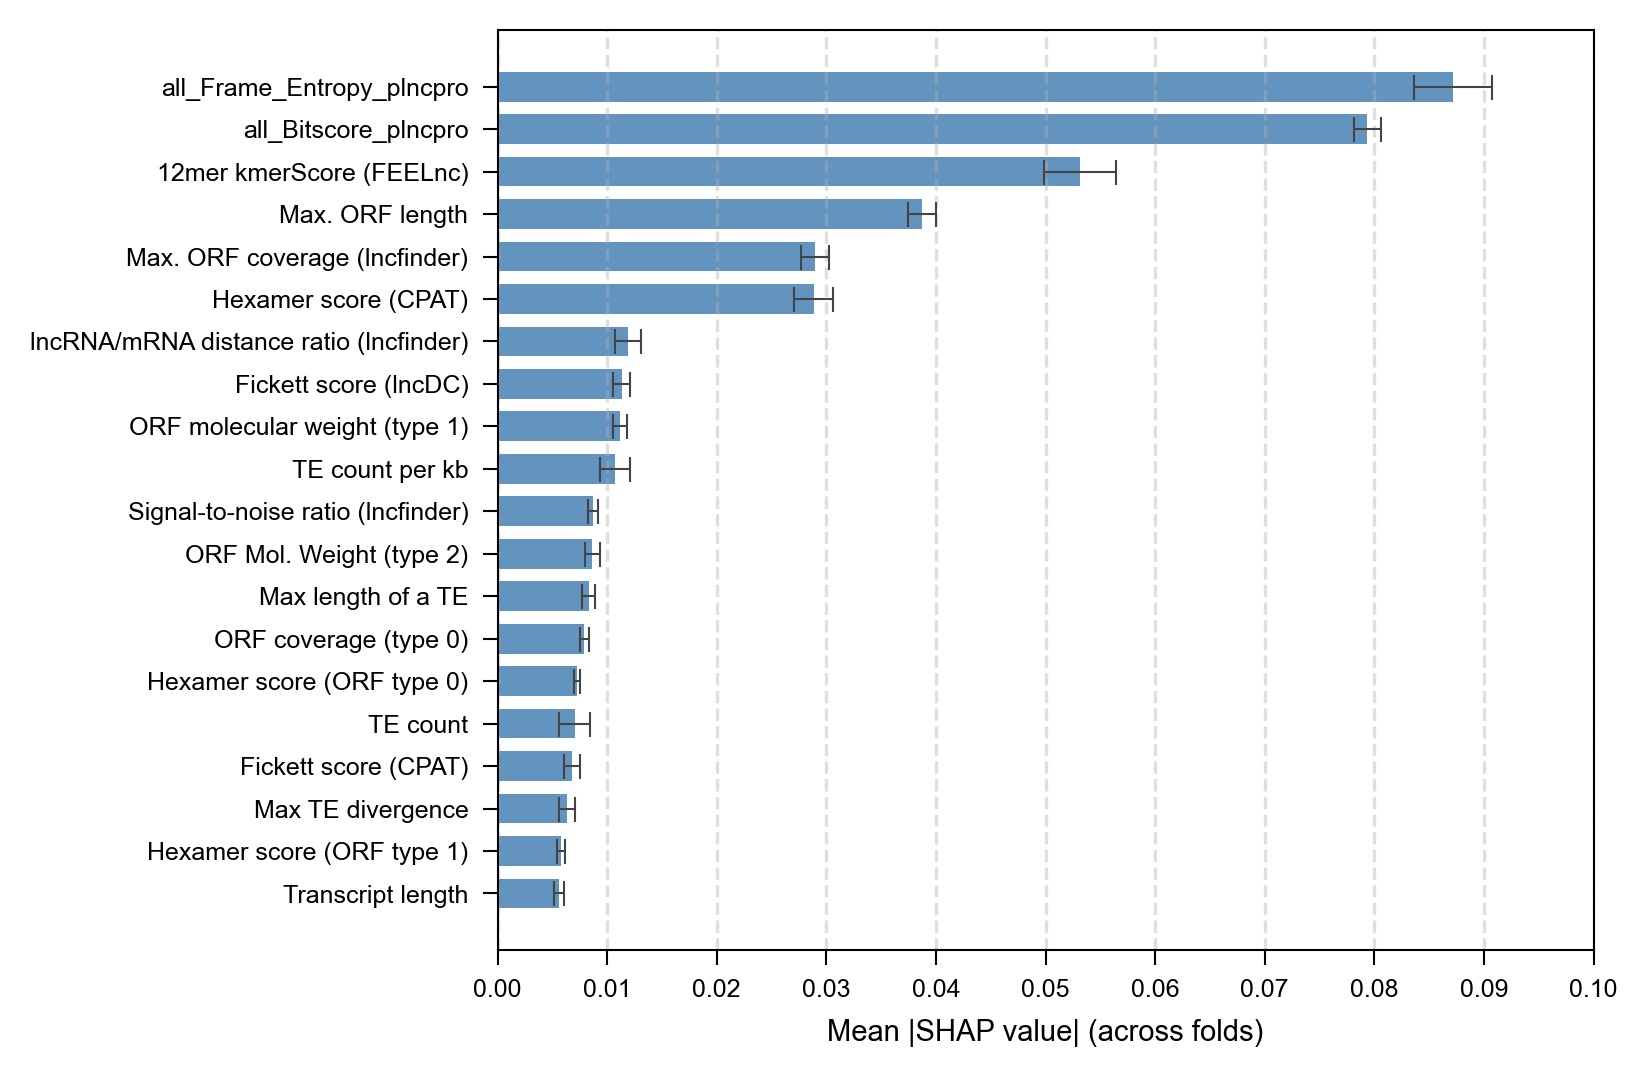

In [ ]:
# ── Feature importance bar chart ──────────────────────────────────────────────
top = shap_agg.head(TOP_N).iloc[::-1].copy()  # reverse so highest is at top
top["label"] = top.index.map(lambda x: feat_dict.get(x, x))

plt.rcParams["figure.dpi"] = DPI
plt.rcParams["font.family"] = "Arial"

# Default line width
plt.rcParams["lines.linewidth"] = 0.5
plt.rcParams["lines.markersize"] = 5
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["axes.linewidth"] = 0.5
# Same for error bars
plt.rcParams["errorbar.capsize"] = 3

w_cm = 14
h_cm = TOP_N * 0.4 + 1.5

fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54))
ax.barh(
    top["label"],
    top["mean_abs_shap"],
    xerr=top["std_abs_shap"],
    color="steelblue",
    ecolor="#444",
    alpha=0.85,
    height=0.7,
    error_kw={
        "elinewidth": 0.5,  # error bar line width
        "capthick": 0.5,    # cap line width
        "capsize": 3,
    },
)
ax.set_xlabel("Mean |SHAP value| (across folds)", fontsize=7)
ax.tick_params(axis="y", labelsize=6)
# ax.set_title(f"Top {TOP_N} features by mean |SHAP|\n{DATASET_LABEL}", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

max_x = (top["mean_abs_shap"] + top["std_abs_shap"]).max()
xmax = np.ceil(max_x / 0.01) * 0.01
ax.set_xlim(0, xmax)
ax.set_xticks(np.arange(0, xmax + 0.01, 0.01))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.01))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# x-axis ticks: 6 pt, 45° rotation
ax.tick_params(axis="x", labelsize=6)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")

maybe_save(fig, "shap_importance_mean_std")
plt.show()

1-SE rule: best=178 features (100.00% ± 0.00); threshold=100.00% -> select 178 features
Selected up to: te_has_ple


  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_cumulative_importance_top30.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_cumulative_importance_top30.png


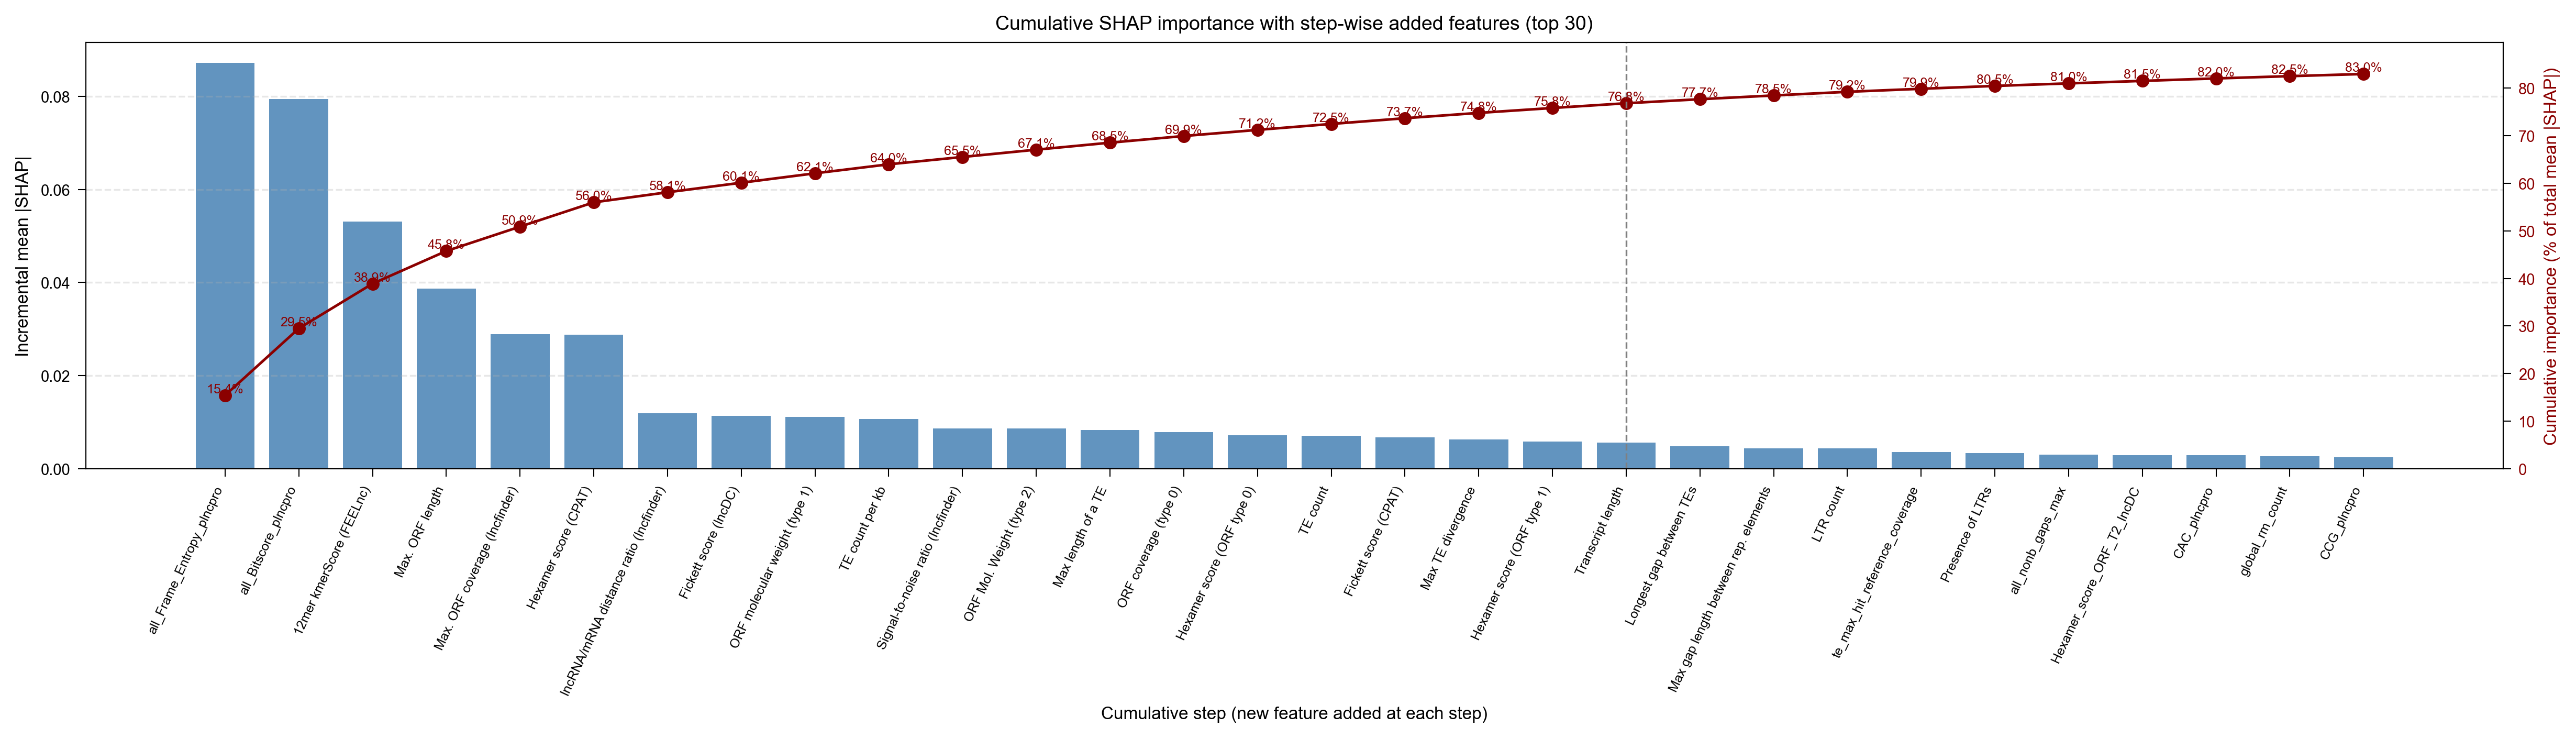

,step,feature,feature_label,mean_abs_shap,cum_pct_total
0,1,all_Frame_Entropy_plncpro,all_Frame_Entropy_plncpro,0.087216,15.443558
1,2,all_Bitscore_plncpro,all_Bitscore_plncpro,0.079371,29.498002
2,3,kmerScore_12mer_feelnc,12mer kmerScore (FEELnc),0.053143,38.908203
3,4,ORF.Max.Len_lncfinder,Max. ORF length,0.038723,45.764888
4,5,ORF.Max.Cov_lncfinder,Max. ORF coverage (lncfinder),0.028942,50.889629
5,6,Hexamer_l_cpat,Hexamer score (CPAT),0.028845,55.997197
6,7,Seq.Dist.Ratio_lncfinder,lncRNA/mRNA distance ratio (lncfinder),0.011937,58.110825
7,8,Fickett_score_lncDC,Fickett score (lncDC),0.011321,60.115494
8,9,ORF_T1_MW_lncDC,ORF molecular weight (type 1),0.011182,62.095453
9,10,te_count_per_kb,TE count per kb,0.010687,63.987862


In [ ]:
# ── Cumulative importance with step-wise feature labels ───────────────────────
cum_imp = (
    shap_agg["mean_abs_shap"]
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="mean_abs_shap")
)
cum_imp["feature_label"] = cum_imp["feature"].map(lambda f: feat_dict.get(f, f))
cum_imp["step"] = np.arange(1, len(cum_imp) + 1)
cum_imp["cum_abs_shap"] = cum_imp["mean_abs_shap"].cumsum()
cum_imp["cum_pct_total"] = 100 * cum_imp["cum_abs_shap"] / cum_imp["mean_abs_shap"].sum()

# RFECV-like 1-SE rule on cumulative SHAP importance across folds
ordered_features = [f for f in cum_imp["feature"] if f in per_fold_mean_abs.columns]

fold_curves = []
for _, row in per_fold_mean_abs[ordered_features].iterrows():
    vals = row.to_numpy(dtype=float)
    total = vals.sum()
    if total > 0:
        fold_curves.append(np.cumsum(vals) / total * 100.0)

fold_curves = np.vstack(fold_curves)
n_cv = fold_curves.shape[0]

mean_curve = fold_curves.mean(axis=0)
std_curve = fold_curves.std(axis=0, ddof=1) if n_cv > 1 else np.zeros_like(mean_curve)
se_curve = std_curve / np.sqrt(n_cv)

cum_imp["cum_pct_mean_cv"] = np.nan
cum_imp["cum_pct_std_cv"] = np.nan
cum_imp["cum_pct_se_cv"] = np.nan
cum_imp.loc[: len(ordered_features) - 1, "cum_pct_mean_cv"] = mean_curve
cum_imp.loc[: len(ordered_features) - 1, "cum_pct_std_cv"] = std_curve
cum_imp.loc[: len(ordered_features) - 1, "cum_pct_se_cv"] = se_curve

best_idx = int(np.nanargmax(mean_curve))
BEST_STEP = best_idx + 1
BEST_MEAN = float(mean_curve[best_idx])
BEST_SE = float(se_curve[best_idx])

ONE_SE_THRESHOLD = BEST_MEAN - BEST_SE
ONE_SE_STEP = int(np.argmax(mean_curve >= ONE_SE_THRESHOLD) + 1)
TOP_N_1SE = ONE_SE_STEP  # RFECV-like selected number of features

print(
    f"1-SE rule: best={BEST_STEP} features ({BEST_MEAN:.2f}% ± {BEST_SE:.2f}); "
    f"threshold={ONE_SE_THRESHOLD:.2f}% -> select {TOP_N_1SE} features"
)
print("Selected up to:", cum_imp.loc[TOP_N_1SE - 1, "feature_label"])


# Number of steps to display (one label per newly added feature)
N_STEPS = min(TOP_N+10, len(cum_imp))
sub = cum_imp.head(N_STEPS).copy()



fig, ax1 = plt.subplots(figsize=(max(9, N_STEPS * 0.55), 4.8), dpi=DPI)

# Incremental contribution of the feature added at each step
ax1.bar(sub["step"], sub["mean_abs_shap"], color="steelblue", alpha=0.85)
ax1.set_xlabel("Cumulative step (new feature added at each step)", fontsize=8)
ax1.set_ylabel("Incremental mean |SHAP|", fontsize=8)
ax1.set_xticks(sub["step"])
ax1.set_xticklabels(sub["feature_label"], rotation=65, ha="right", fontsize=6)
ax1.tick_params(axis="y", labelsize=7)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Cumulative importance curve (% of total importance over all features)
ax2 = ax1.twinx()
ax2.plot(sub["step"], sub["cum_pct_total"], color="darkred", marker="o", lw=1.2)
ax2.set_ylabel("Cumulative importance (% of total mean |SHAP|)", color="darkred", fontsize=8)
ax2.tick_params(axis="y", labelcolor="darkred", labelsize=7)
ax2.set_ylim(0, min(100, sub["cum_pct_total"].max() * 1.08))

# Vertical line at TOP_N
ax2.axvline(x=TOP_N, color="gray", linestyle="--", lw=0.8)

for x, y in zip(sub["step"], sub["cum_pct_total"]):
    ax2.text(x, y, f"{y:.1f}%", fontsize=6, color="darkred", ha="center", va="bottom")

plt.title(f"Cumulative SHAP importance with step-wise added features (top {N_STEPS})", fontsize=9)
plt.tight_layout()

if "maybe_save" in globals():
    maybe_save(fig, f"shap_cumulative_importance_top{N_STEPS}")

plt.show()

sub[["step", "feature", "feature_label", "mean_abs_shap", "cum_pct_total"]]

### Plot 2 — Per-fold mean |SHAP| heatmap (features × folds)

  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_fold_heatmap.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/shap_fold_heatmap.png


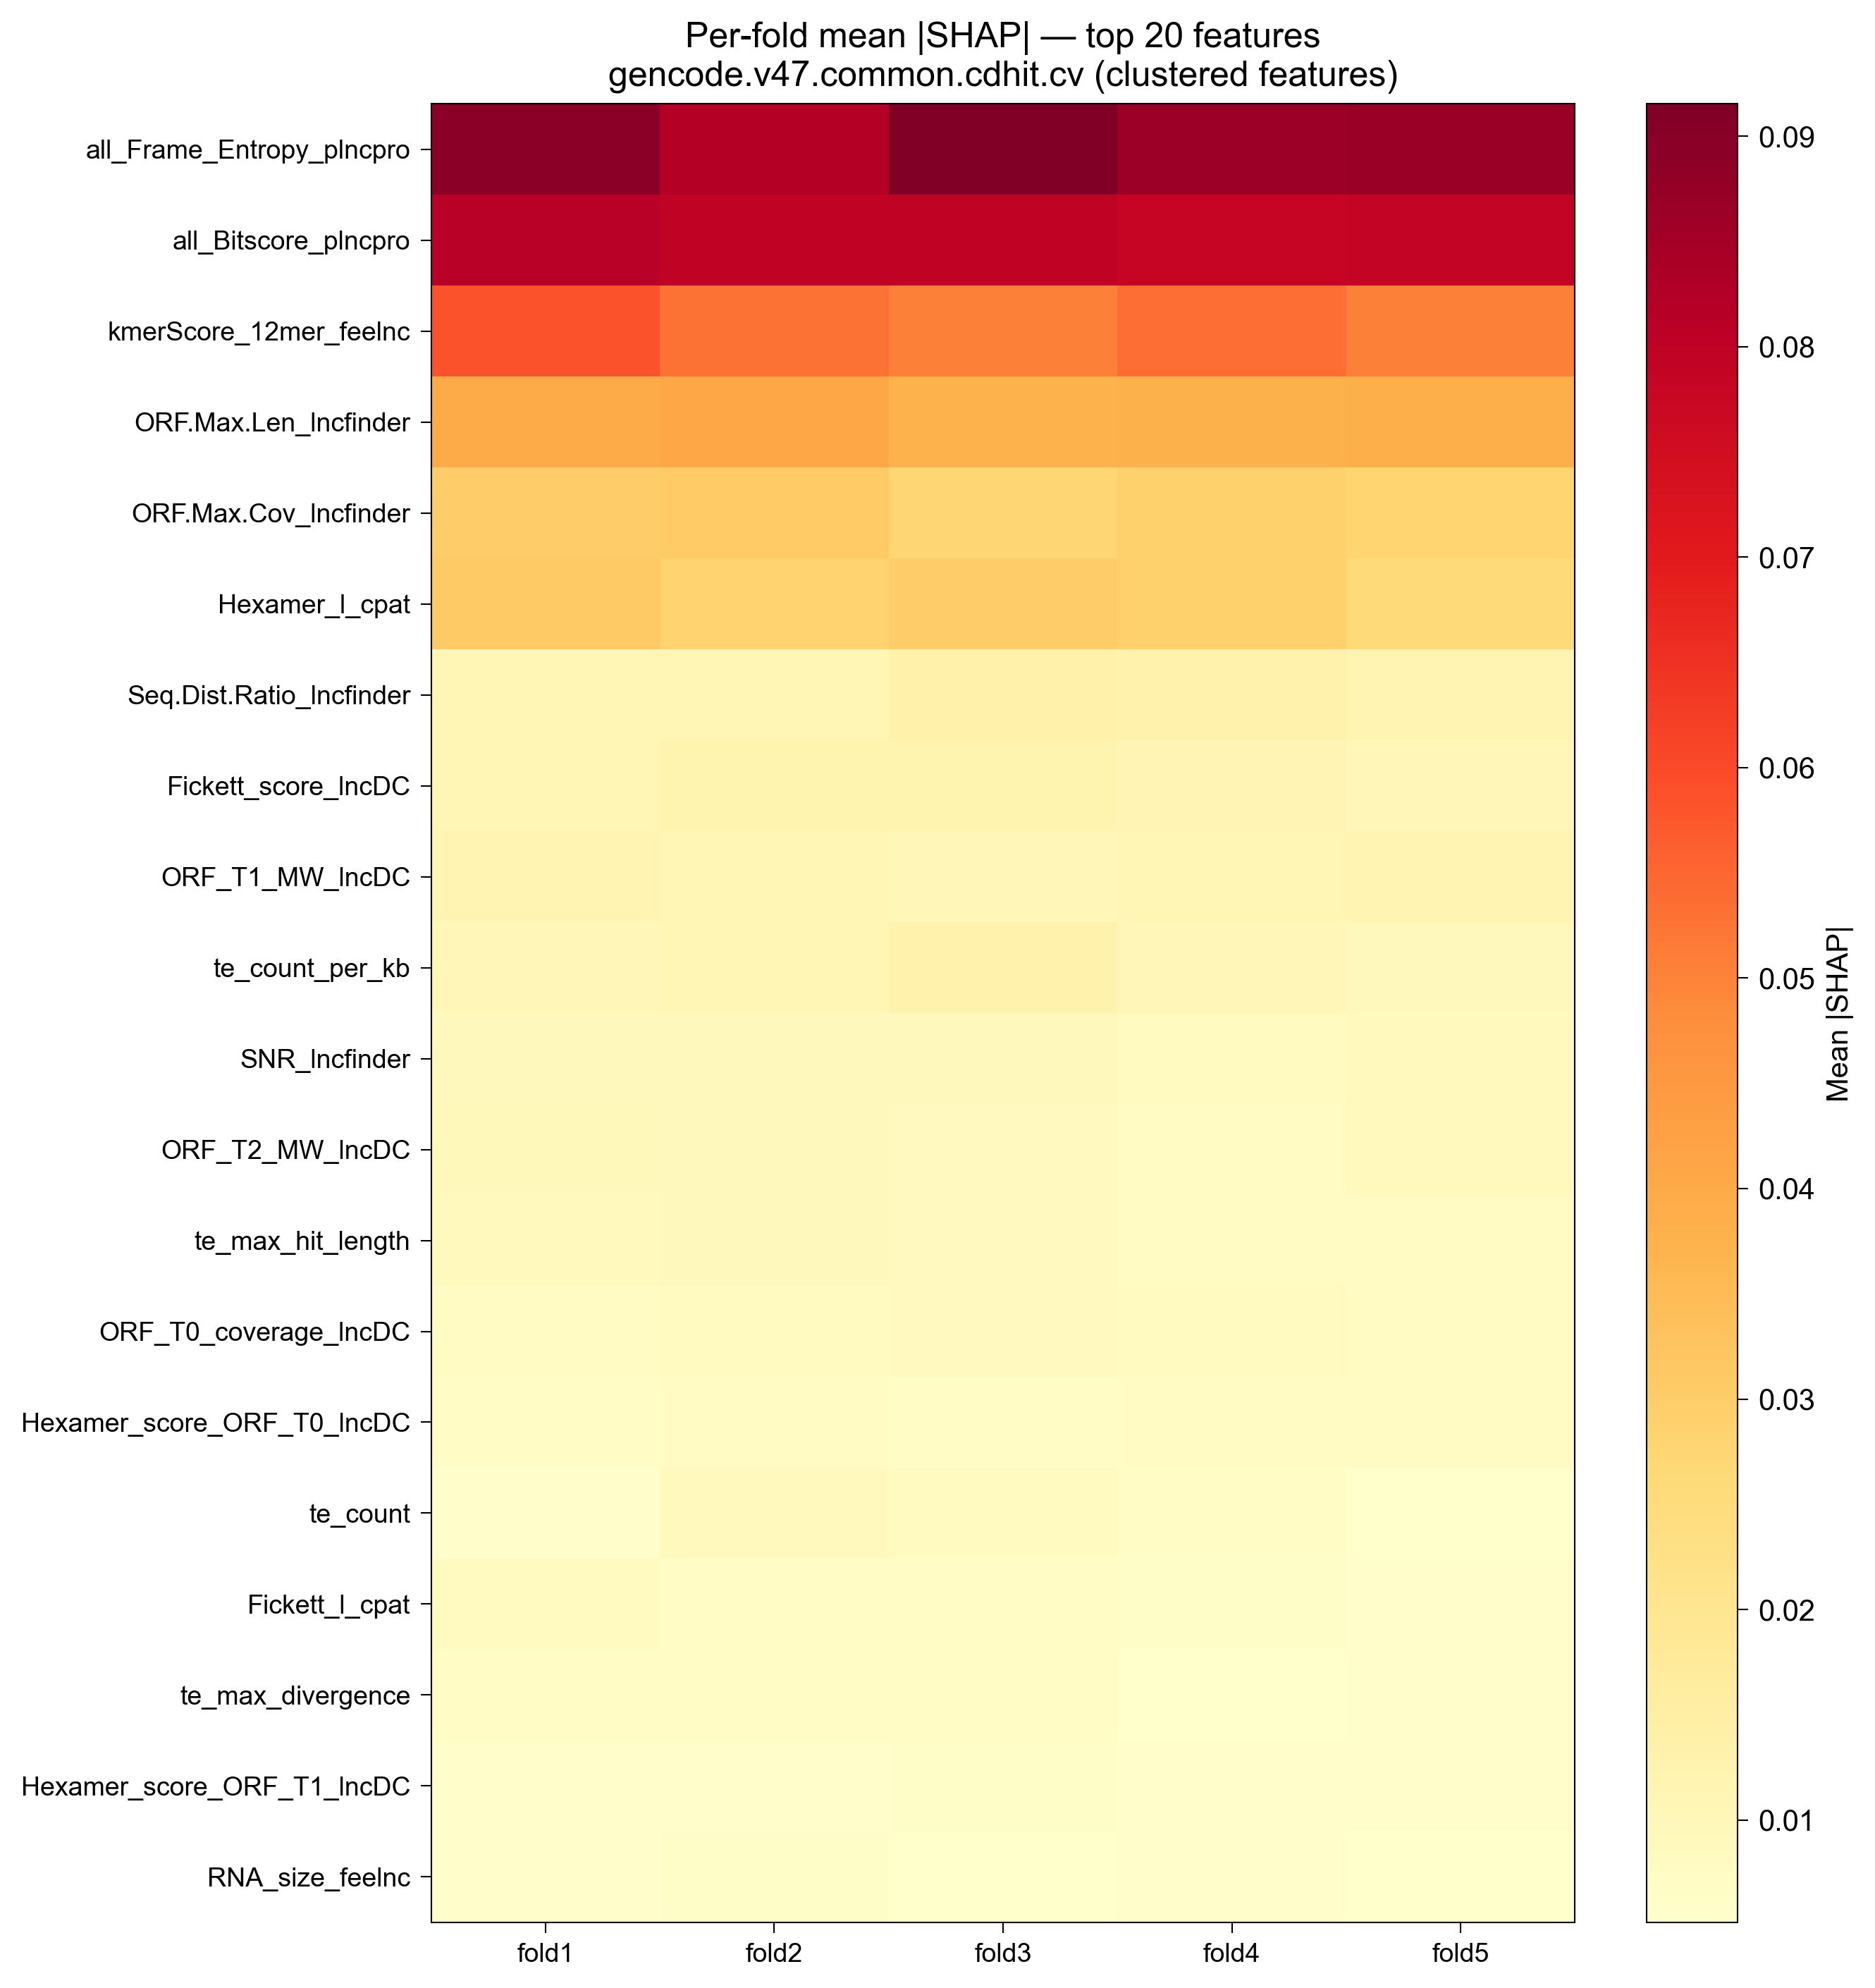

In [ ]:
# ── Per-fold heatmap ──────────────────────────────────────────────────────────
top_feats = shap_agg.head(TOP_N).index
data = per_fold_mean_abs[top_feats].T  # features × folds

n_folds_loaded = per_fold_mean_abs.shape[0]
fig, ax = plt.subplots(figsize=(n_folds_loaded * 1.4 + 2, TOP_N * 0.4 + 1.5))
im = ax.imshow(data.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(n_folds_loaded))
ax.set_xticklabels(per_fold_mean_abs.index, fontsize=9)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats, fontsize=9)
plt.colorbar(im, ax=ax, label="Mean |SHAP|")
ax.set_title(f"Per-fold mean |SHAP| — top {TOP_N} features\n{DATASET_LABEL}", fontsize=12)
plt.tight_layout()

maybe_save(fig, "shap_fold_heatmap")
plt.show()

### Plot 3 — Beeswarm over all evaluated transcripts

  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/beeswarm_all_transcripts.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/beeswarm_all_transcripts.png


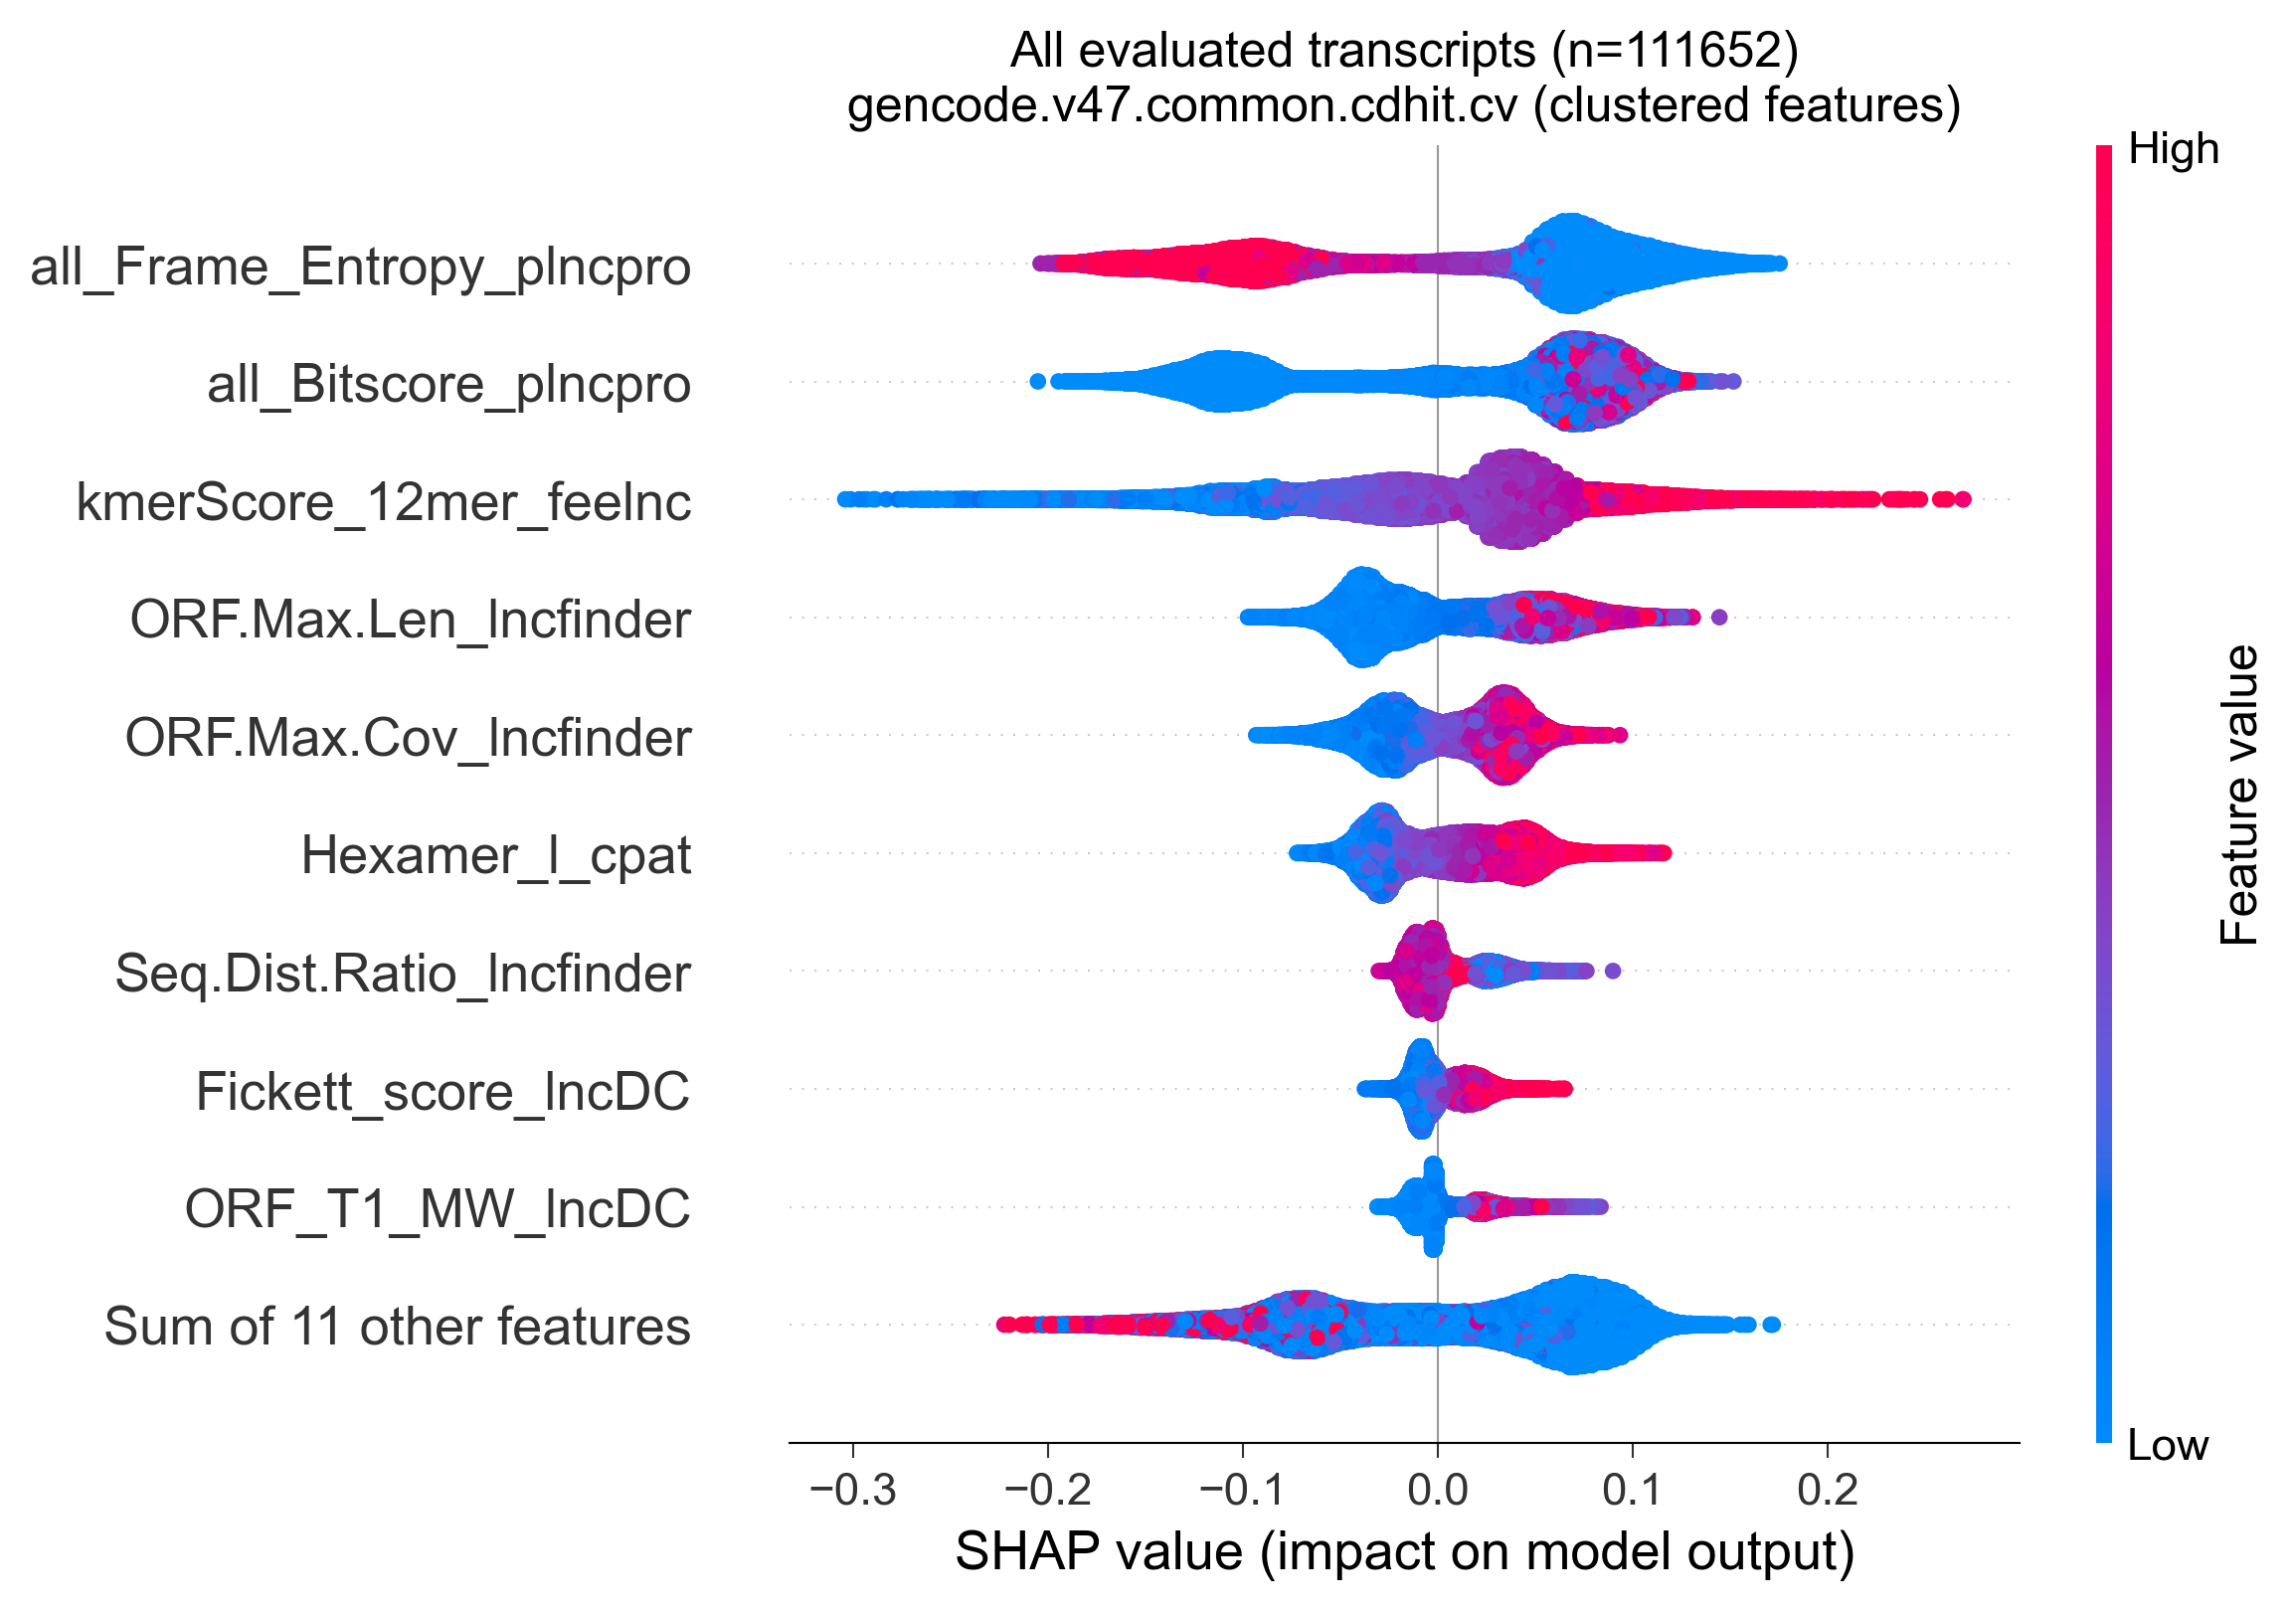

In [ ]:
# ── Beeswarm (all transcripts pooled across folds) ────────────────────────────
all_sv, all_xv = [], []
for res in fold_data.values():
    sv = res["shap_df"].reindex(columns=top_feats, fill_value=0).values
    xv = res["X_test"].reindex(columns=top_feats, fill_value=0).values
    all_sv.append(sv)
    all_xv.append(xv)

sv_mat = np.vstack(all_sv)
x_mat = np.vstack(all_xv)
expl = shap.Explanation(values=sv_mat, data=x_mat, feature_names=list(top_feats))

fig = plt.figure(figsize=(10, 6))
shap.plots.beeswarm(expl, show=False)
plt.title(f"All evaluated transcripts (n={sv_mat.shape[0]})\n{DATASET_LABEL}", fontsize=12)
plt.tight_layout()

maybe_save(fig, "beeswarm_all_transcripts")
plt.show()

### Plot 4 — Predicted probability distribution (class 1 / lncRNA)

  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/prediction_probability_distribution.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/prediction_probability_distribution.png


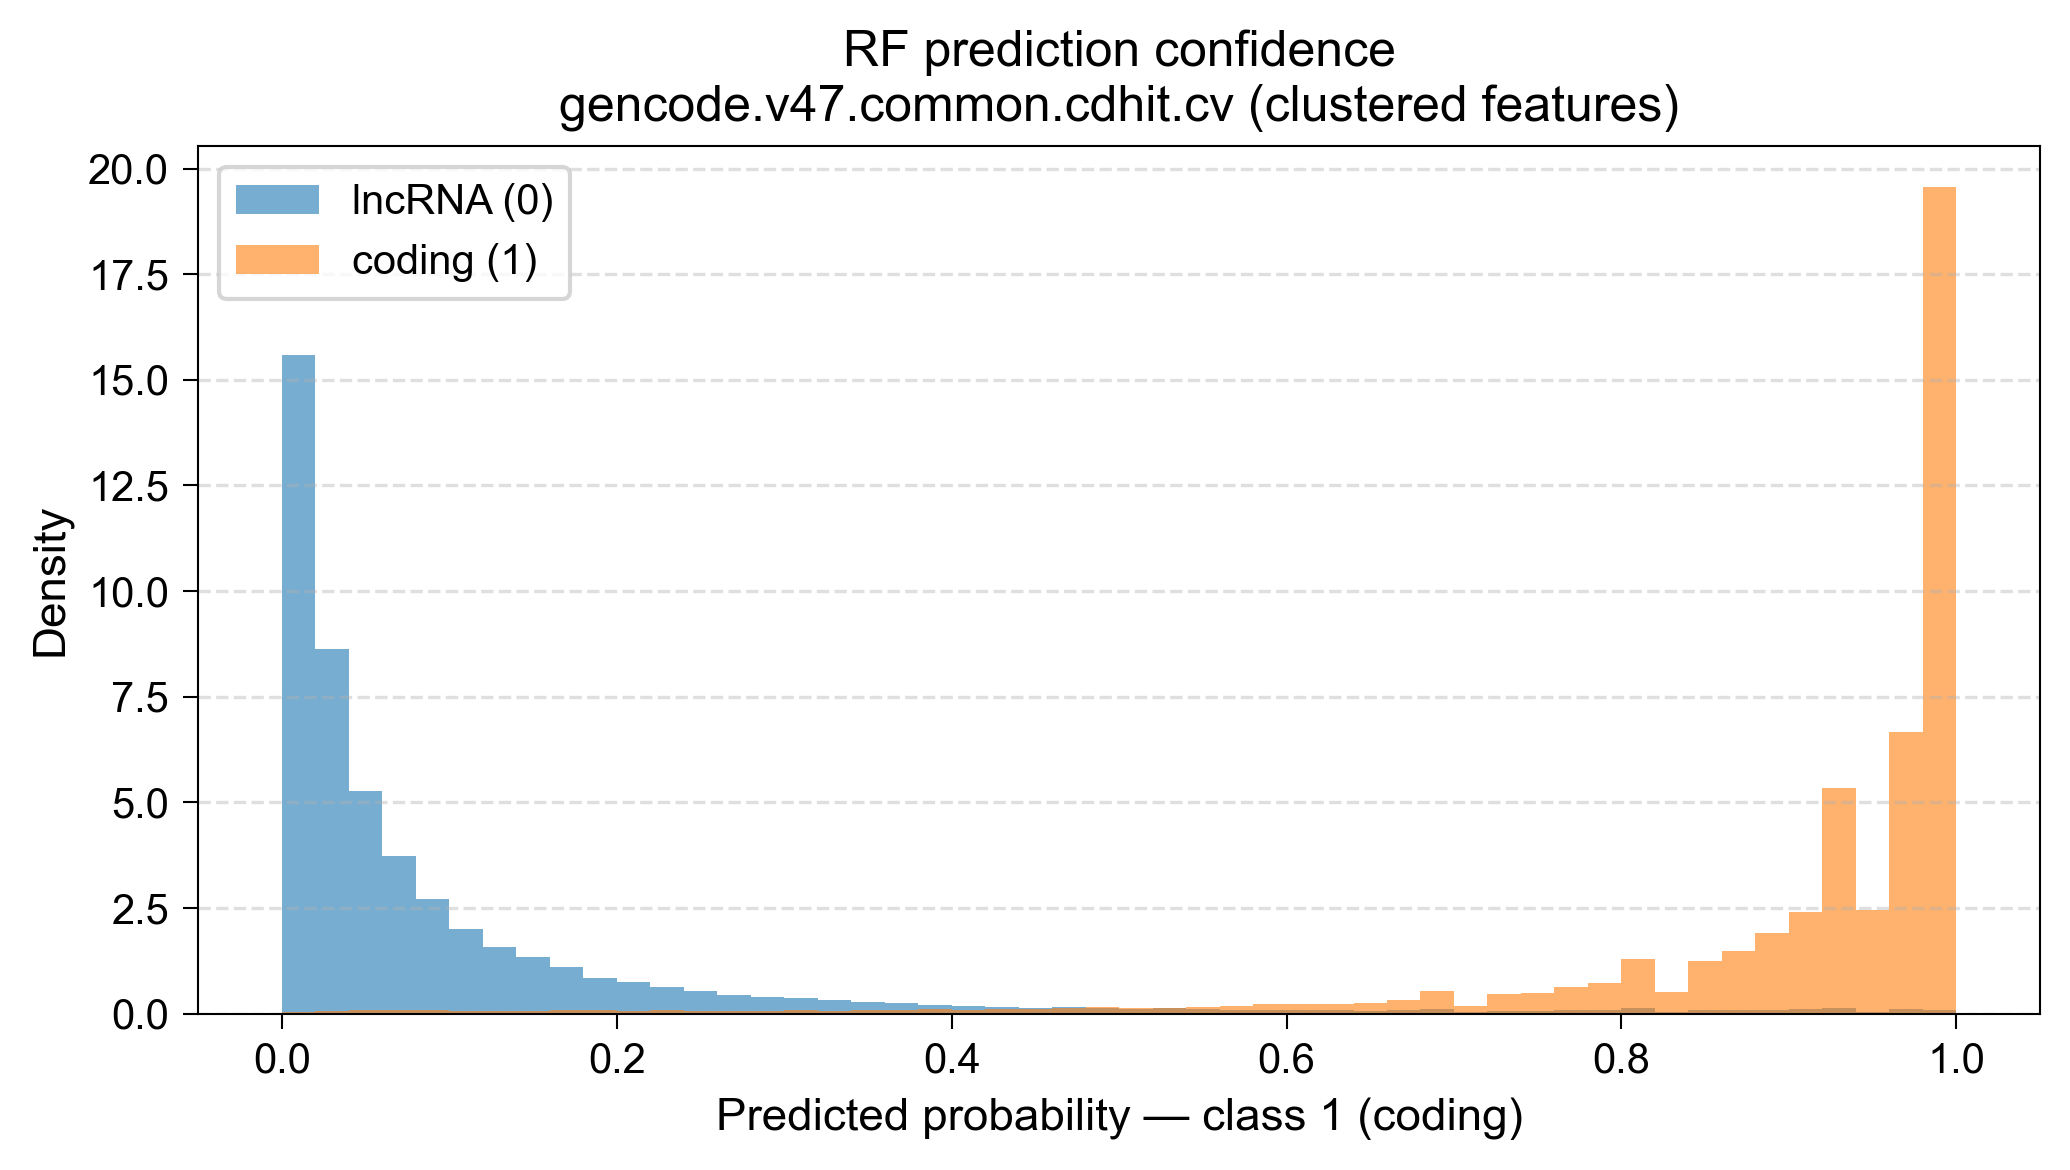

In [ ]:
# ── Predicted probability distribution split by true label ────────────────────
prob_col = "y_pred_proba_class_1"

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in combined_preds.groupby("y_true"):
    clsname = "coding (1)" if label == 1 else "lncRNA (0)"
    ax.hist(grp[prob_col], bins=50, alpha=0.6, label=clsname, density=True)
ax.set_xlabel("Predicted probability — class 1 (coding)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(f"RF prediction confidence\n{DATASET_LABEL}", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

maybe_save(fig, "prediction_probability_distribution")
plt.show()

## Plot 5 –– Waterfall plots for selected transcripts

Here is a list of selected transcripts by entropy and coding groups, with both IDs stripped of version and their name.

low_pc = ['ENST00000265171', 'ENST00000522362', 'ENST00000293599', 'ENST00000704677', 'ENST00000342193', 'ENST00000554192', 'ENST00000674628', 'ENST00000713679']
low_pc = ['EGF', 'PNMA2', 'AQP5', 'UPF1', 'COBLL1', 'AKT1', 'DICER1', 'BRCA2']
low_lnc = ['ENST00000434839', 'ENST00000710870']
low_lnc = ['XIST', 'MALAT1']
high_pc = ['ENST00000361567', 'ENST00000503087', 'ENST00000608796', 'ENST00000581411', 'ENST00000651610']
high_pc = ['MT-ND5', 'TGFBI', 'SWI5', 'TP53I13', 'AQP1']
high_lnc = ['ENST00000524131', 'ENST00000554894']
high_lnc = ['MEG3', 'CHASERR']

# ── Cherry-pick definitions ───────────────────────────────────────────────────
cherry_pick: dict[str, list[str]] = {
    "low_entropy_coding":  ["ENST00000265171", "ENST00000522362", "ENST00000293599",
                            "ENST00000704677", "ENST00000342193", "ENST00000554192",
                            "ENST00000674628", "ENST00000713679"],
    "low_entropy_lncrna":  ["ENST00000434839", "ENST00000710870"],
    "high_entropy_coding": ["ENST00000361567", "ENST00000503087", "ENST00000608796",
                            "ENST00000581411", "ENST00000651610"],
    "high_entropy_lncrna": ["ENST00000524131", "ENST00000554894"],
}

cherry_names: dict[str, list[str]] = {
    "low_entropy_coding":  ["EGF", "PNMA2", "AQP5", "UPF1", "COBLL1", "AKT1", "DICER1", "BRCA2"],
    "low_entropy_lncrna":  ["XIST", "MALAT1"],
    "high_entropy_coding": ["MT-ND5", "TGFBI", "SWI5", "TP53I13", "AQP1"],
    "high_entropy_lncrna": ["MEG3", "CHASERR"],
}

In [ ]:
# ── Cherry-pick definitions ───────────────────────────────────────────────────
cherry_pick: dict[str, list[str]] = {
    "low_entropy_coding":  ["ENST00000265171"],
    "low_entropy_lncrna":  ["ENST00000710870"],
    "high_entropy_coding": ["ENST00000608796"],
    "high_entropy_lncrna": ["ENST00000524131"],
}

cherry_names: dict[str, list[str]] = {
    "low_entropy_coding":  ["EGF"],
    "low_entropy_lncrna":  ["MALAT1"],
    "high_entropy_coding": ["SWI5"],
    "high_entropy_lncrna": ["MEG3"],
}

# Number of top features to display in each waterfall
WATERFALL_MAX_DISPLAY: int = 11

# ── Waterfall figure style ────────────────────────────────────────────────────
WATERFALL_W_CM: float = 8.0       # figure width  (cm)
WATERFALL_H_CM: float = 4.0       # figure height (cm)
WATERFALL_DPI: int = 300           # display & save resolution
WATERFALL_FONT_PT: float = 7.0    # body text size (pt)
WATERFALL_TITLE_PT: float = 8.0   # suptitle size  (pt)
WATERFALL_POS_COLOR = (0.86, 0.08, 0.24)   # RGB — positive SHAP (pushes toward coding)
WATERFALL_NEG_COLOR = (0.13, 0.47, 0.71)   # RGB — negative SHAP (pushes toward lncRNA)


# ── Helpers ───────────────────────────────────────────────────────────────────
def build_transcript_index(fold_data: dict) -> dict:
    """Map short ENSEMBL ID (no version) → (fold_i, full versioned ID)."""
    index: dict = {}
    for fold_i, res in fold_data.items():
        for full_id in res["shap_df"].index:
            short = full_id.split(".")[0]
            index[short] = (fold_i, full_id)
    return index


def get_shap_row(tid: str, index: dict, fold_data: dict):
    """Return (shap_series, fold_i, full_id) or (None, None, None) if missing."""
    short = tid.split(".")[0]
    if short not in index:
        return None, None, None
    fold_i, full_id = index[short]
    return fold_data[fold_i]["shap_df"].loc[full_id], fold_i, full_id


transcript_index = build_transcript_index(fold_data)
print(f"Transcript index: {len(transcript_index):,} entries")

# Verify which cherry-picks are present in any test fold
for group, tids in cherry_pick.items():
    names = cherry_names[group]
    for tid, name in zip(tids, names):
        found = tid.split(".")[0] in transcript_index
        print(f"  {'✓' if found else '✗'}  {group:25s}  {tid}  ({name})")

Transcript index: 111,652 entries
  ✓  low_entropy_coding         ENST00000265171  (EGF)
  ✓  low_entropy_lncrna         ENST00000710870  (MALAT1)
  ✓  high_entropy_coding        ENST00000608796  (SWI5)
  ✓  high_entropy_lncrna        ENST00000524131  (MEG3)


### SHAP without mods


────────────────────────────────────────────────────────────
  Low-entropy coding (mRNA)
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_coding_EGF_old.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_coding_EGF_old.png


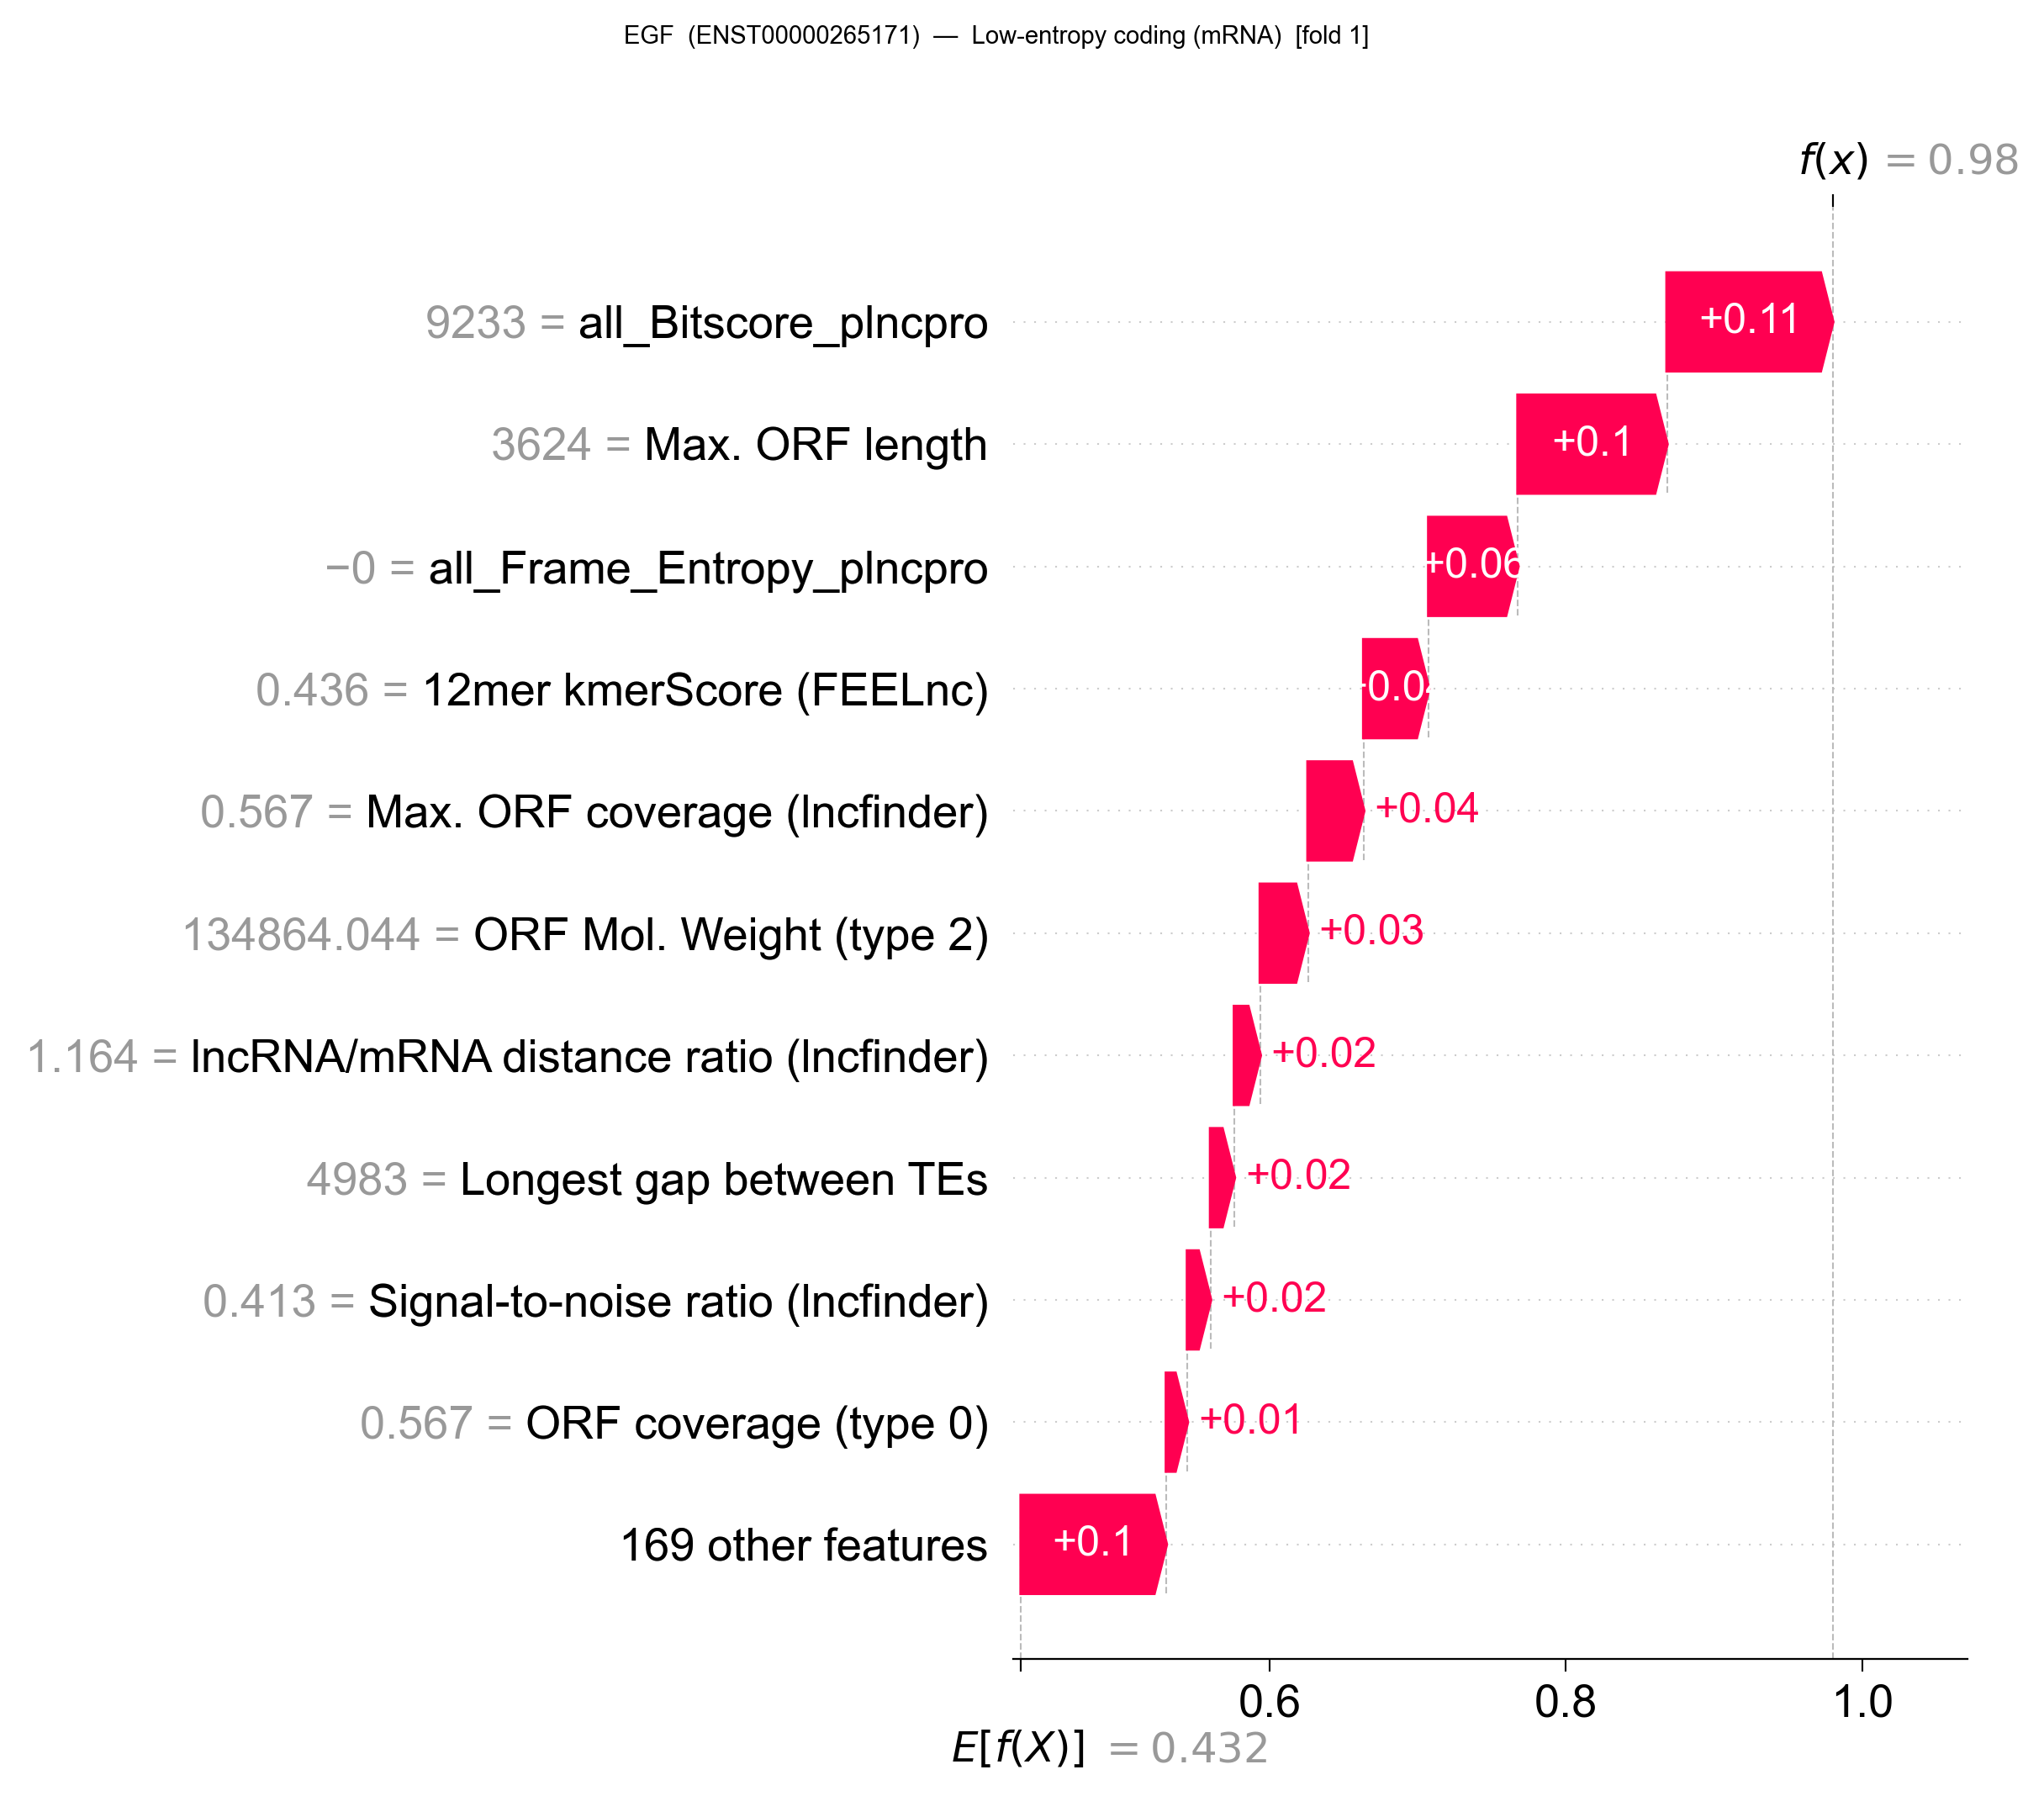


────────────────────────────────────────────────────────────
  Low-entropy non-coding (lncRNA)
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_lncrna_MALAT1_old.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_lncrna_MALAT1_old.png


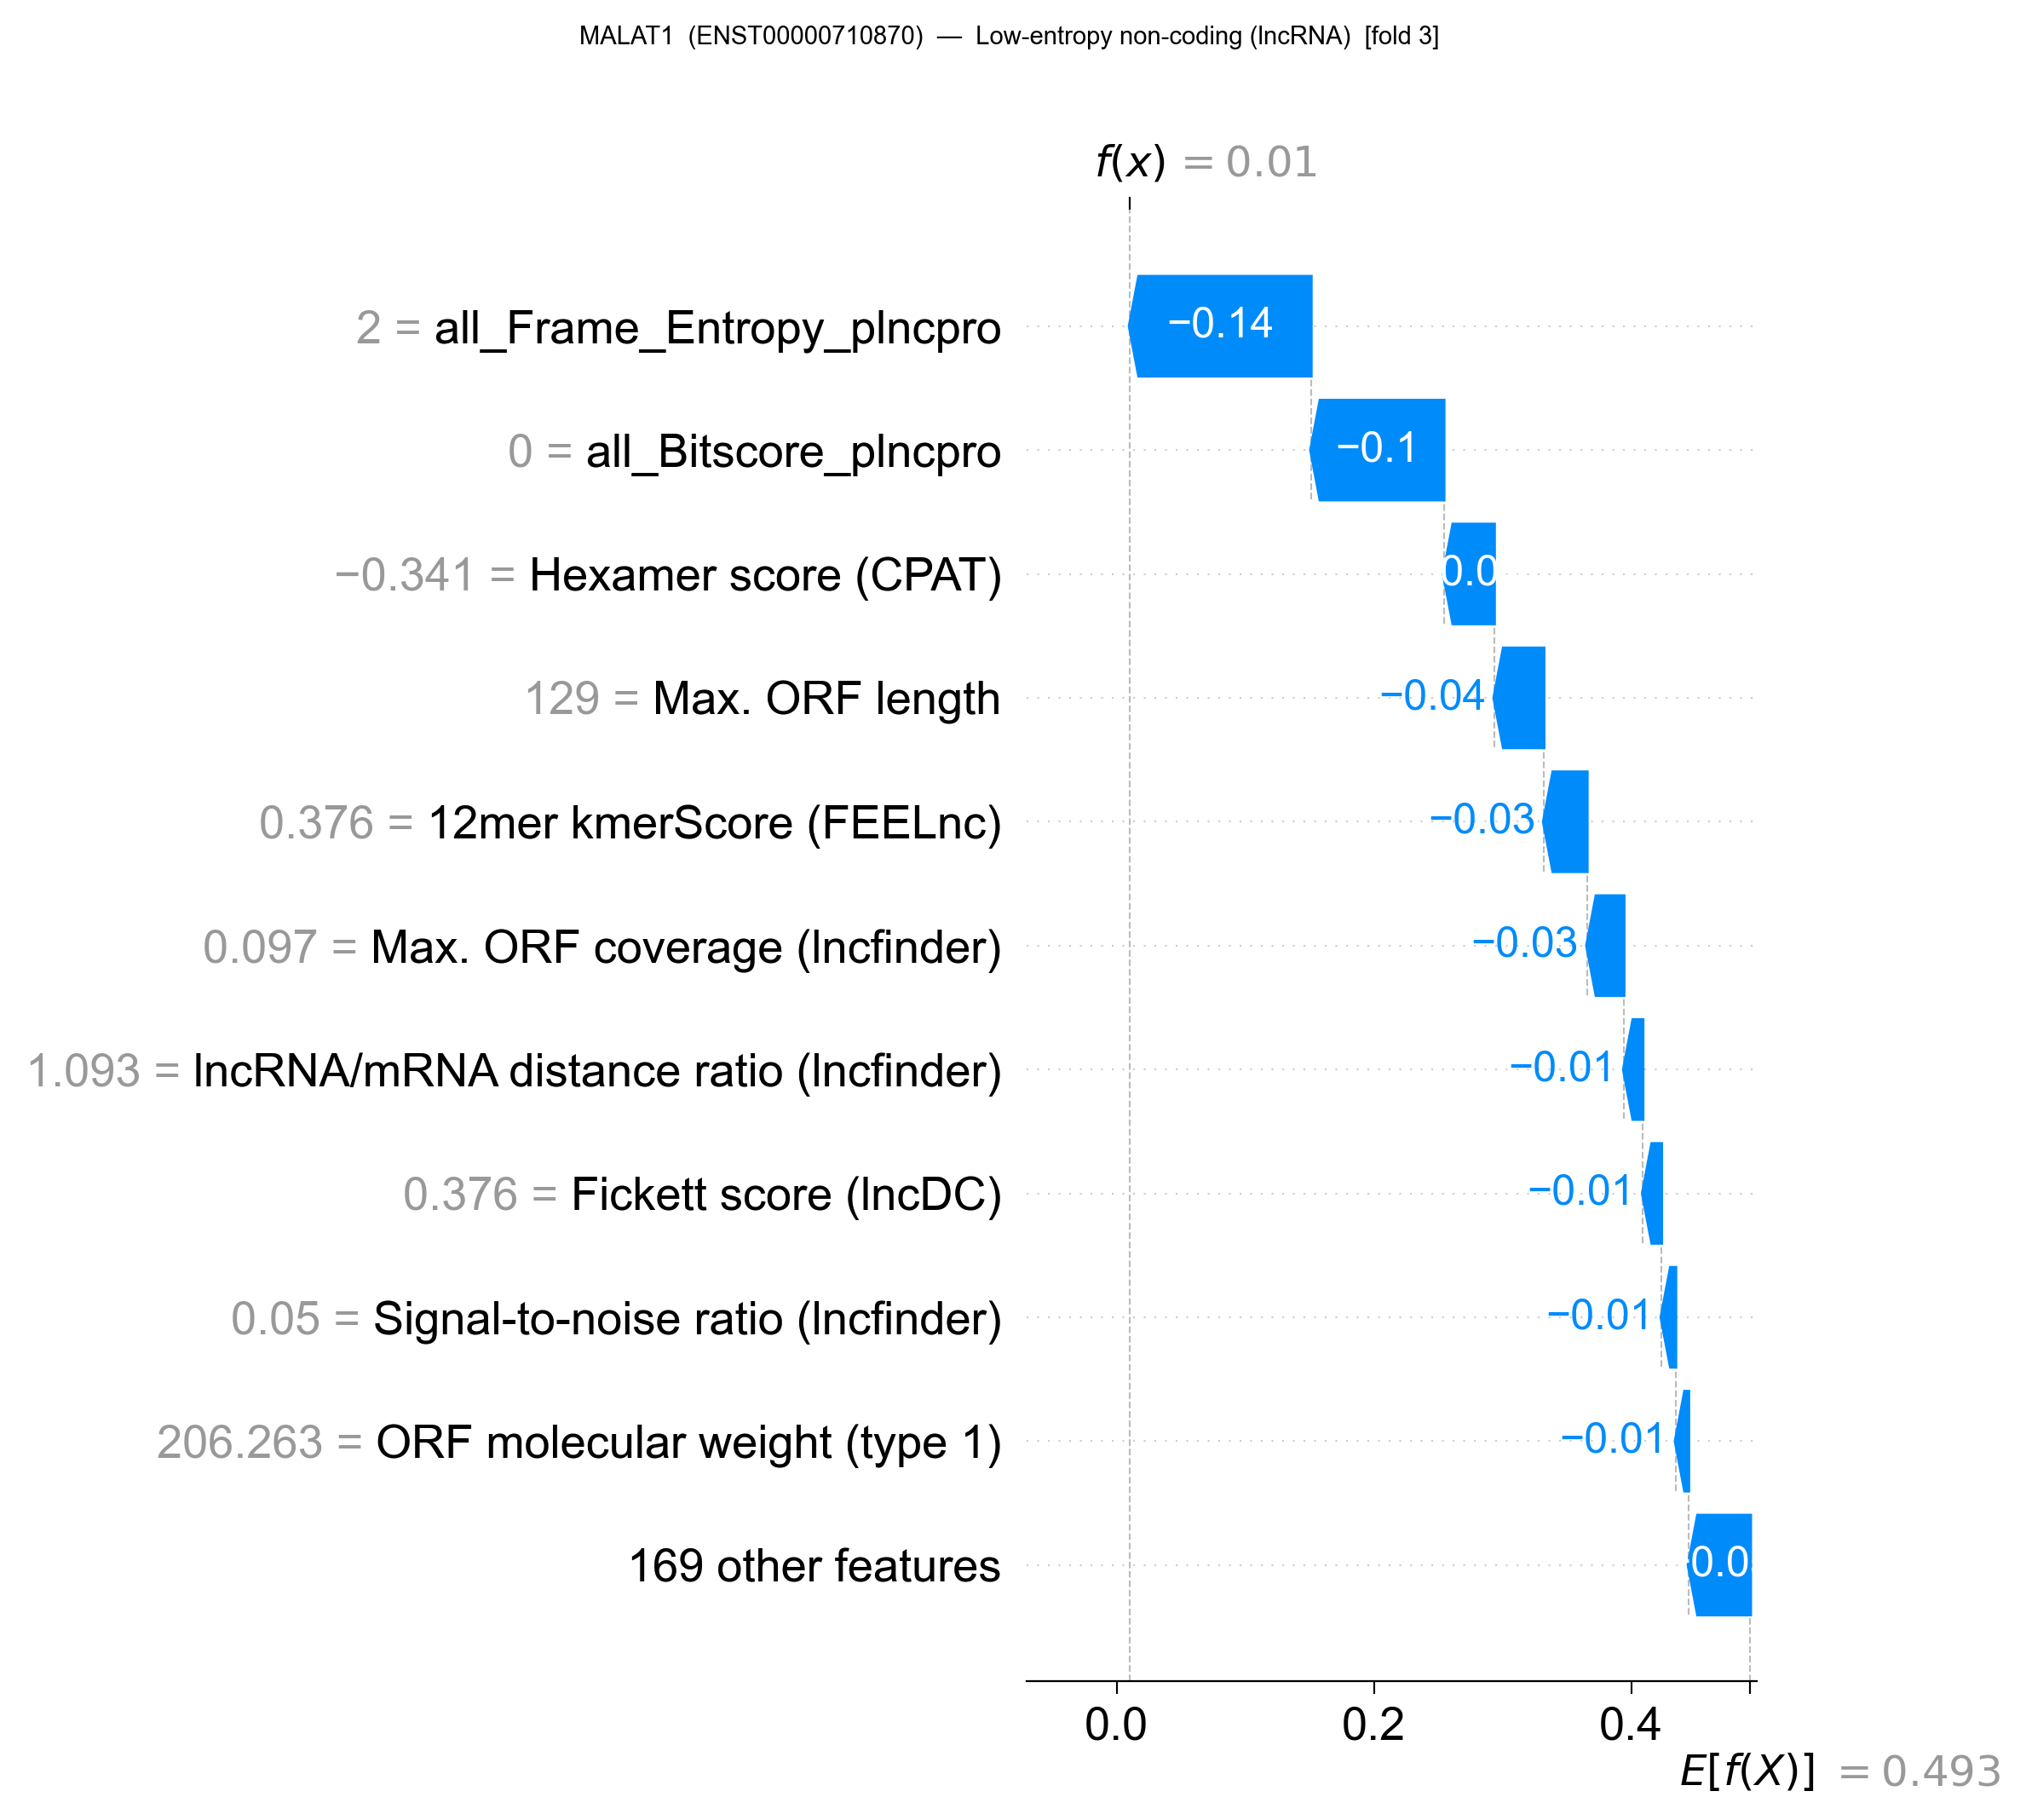


────────────────────────────────────────────────────────────
  High-entropy coding (mRNA)
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_coding_SWI5_old.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_coding_SWI5_old.png


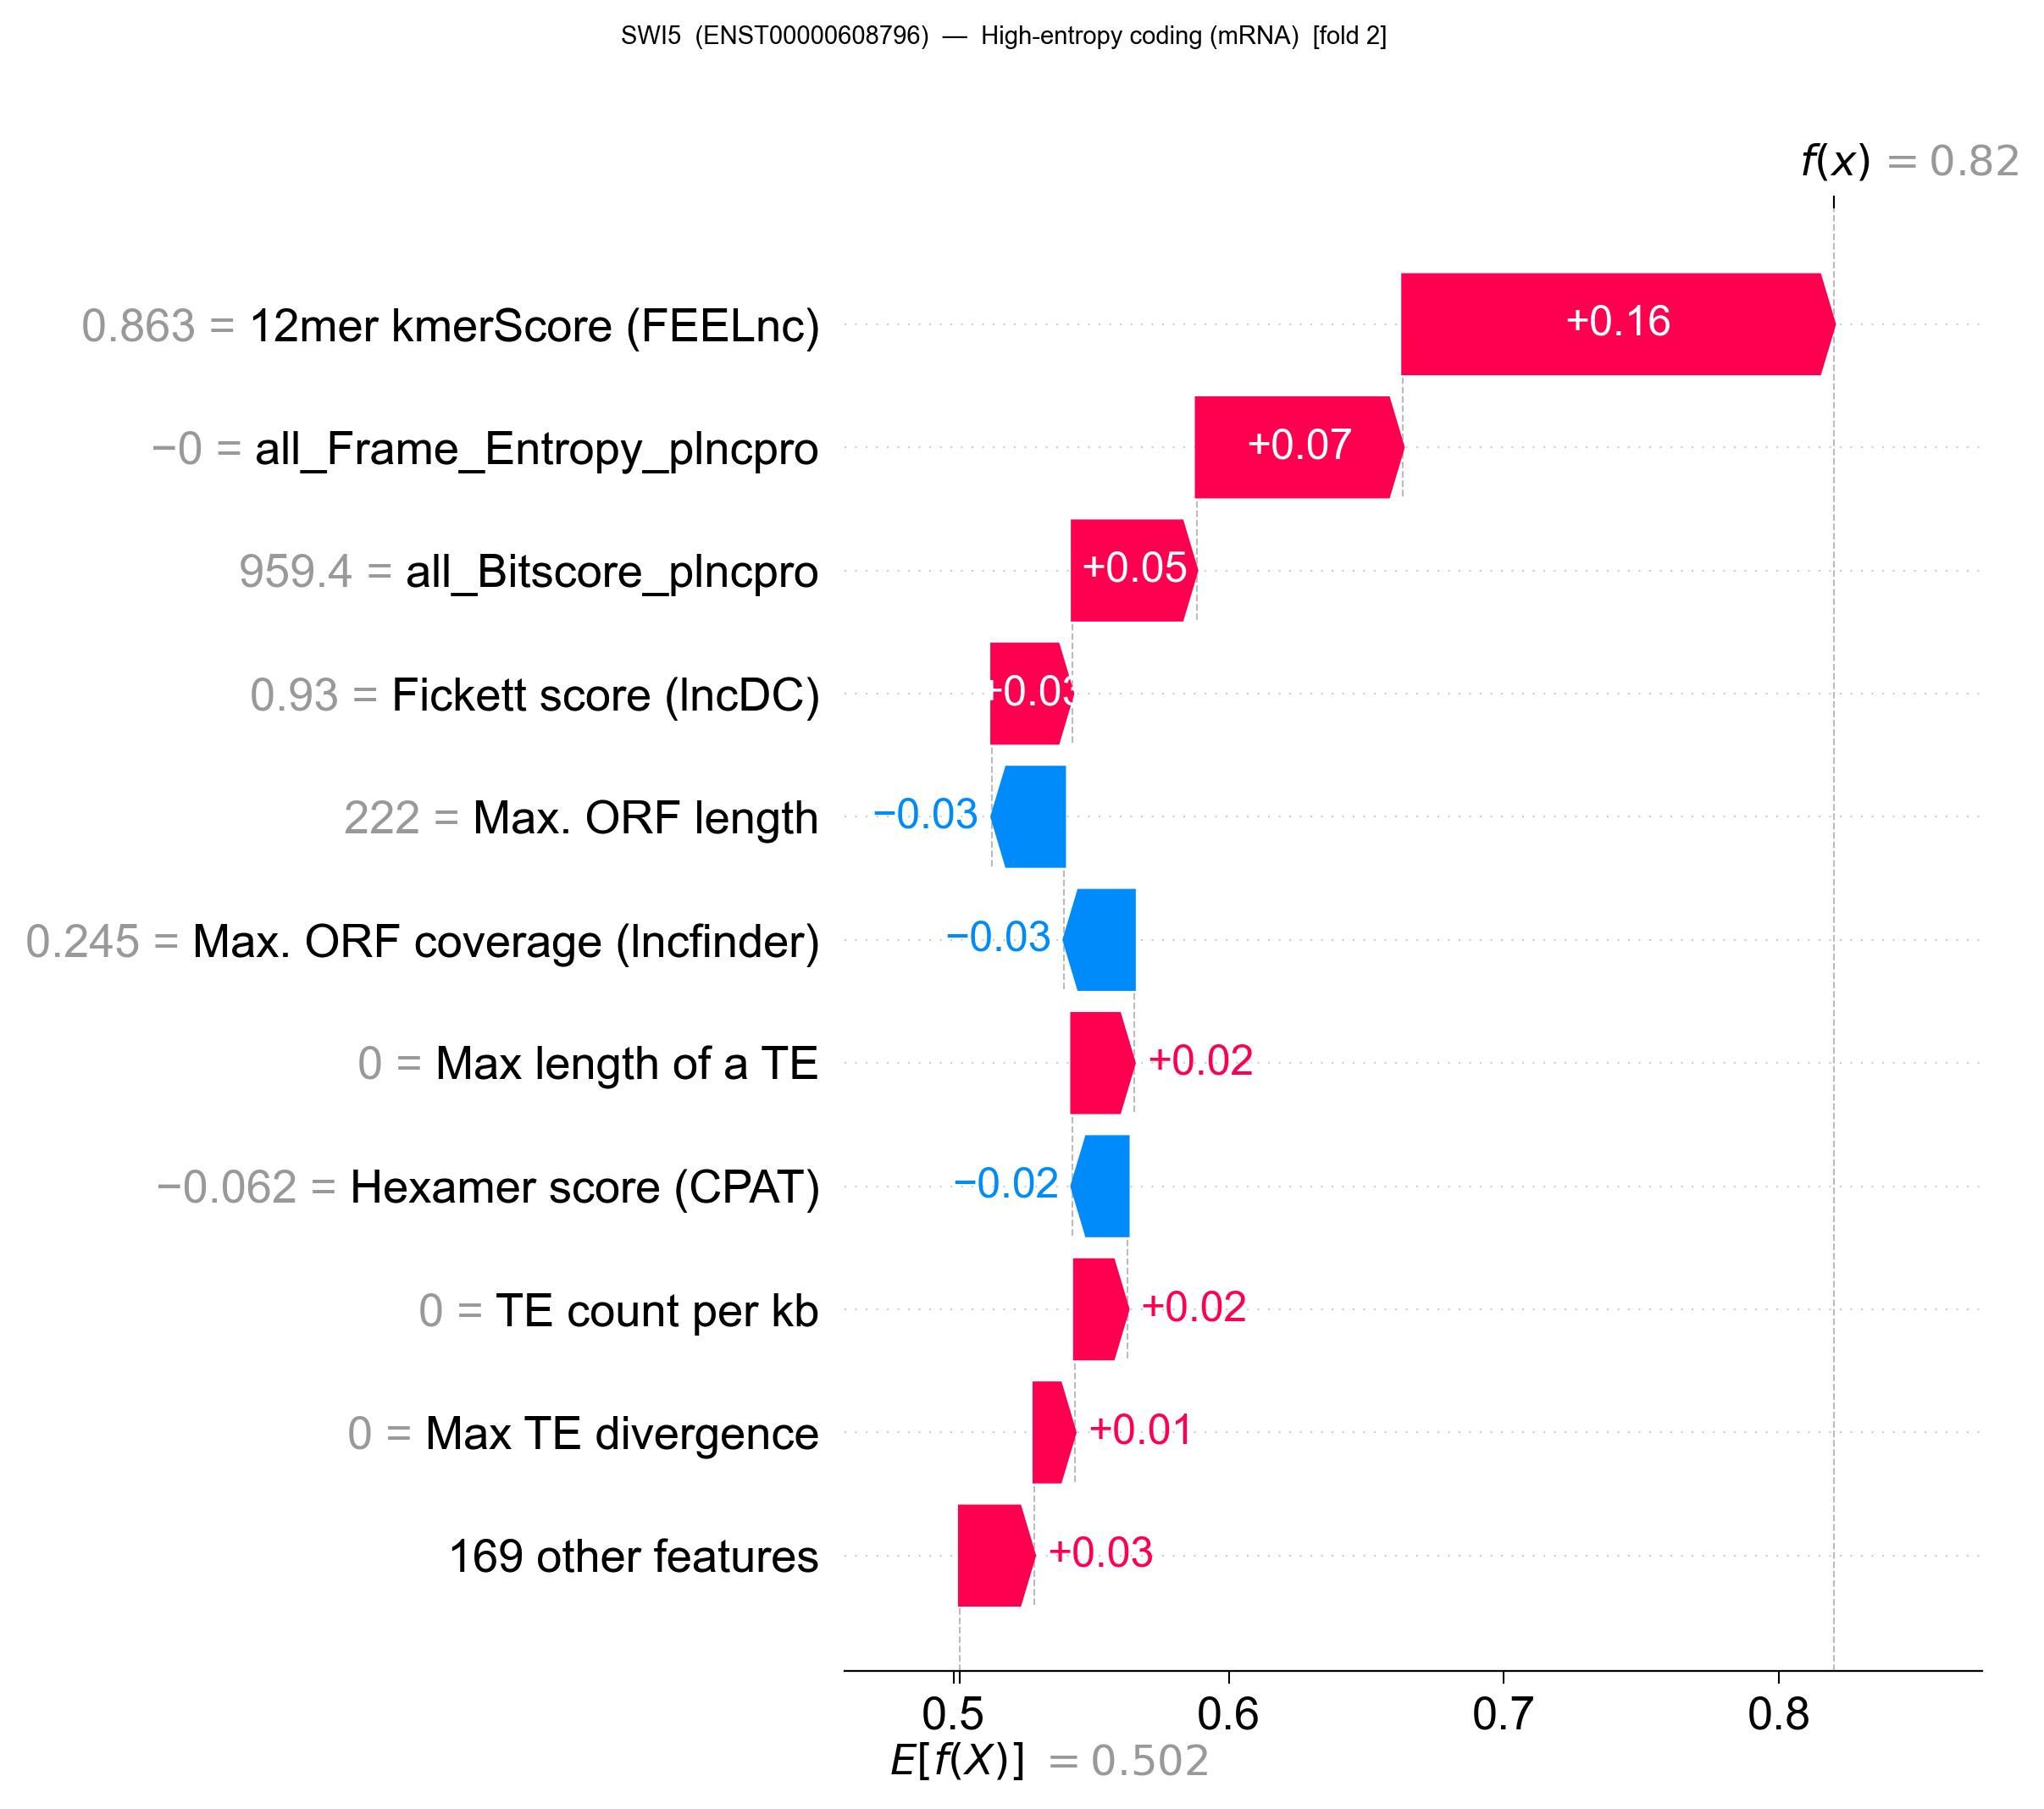


────────────────────────────────────────────────────────────
  High-entropy non-coding (lncRNA)
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_lncrna_MEG3_old.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_lncrna_MEG3_old.png


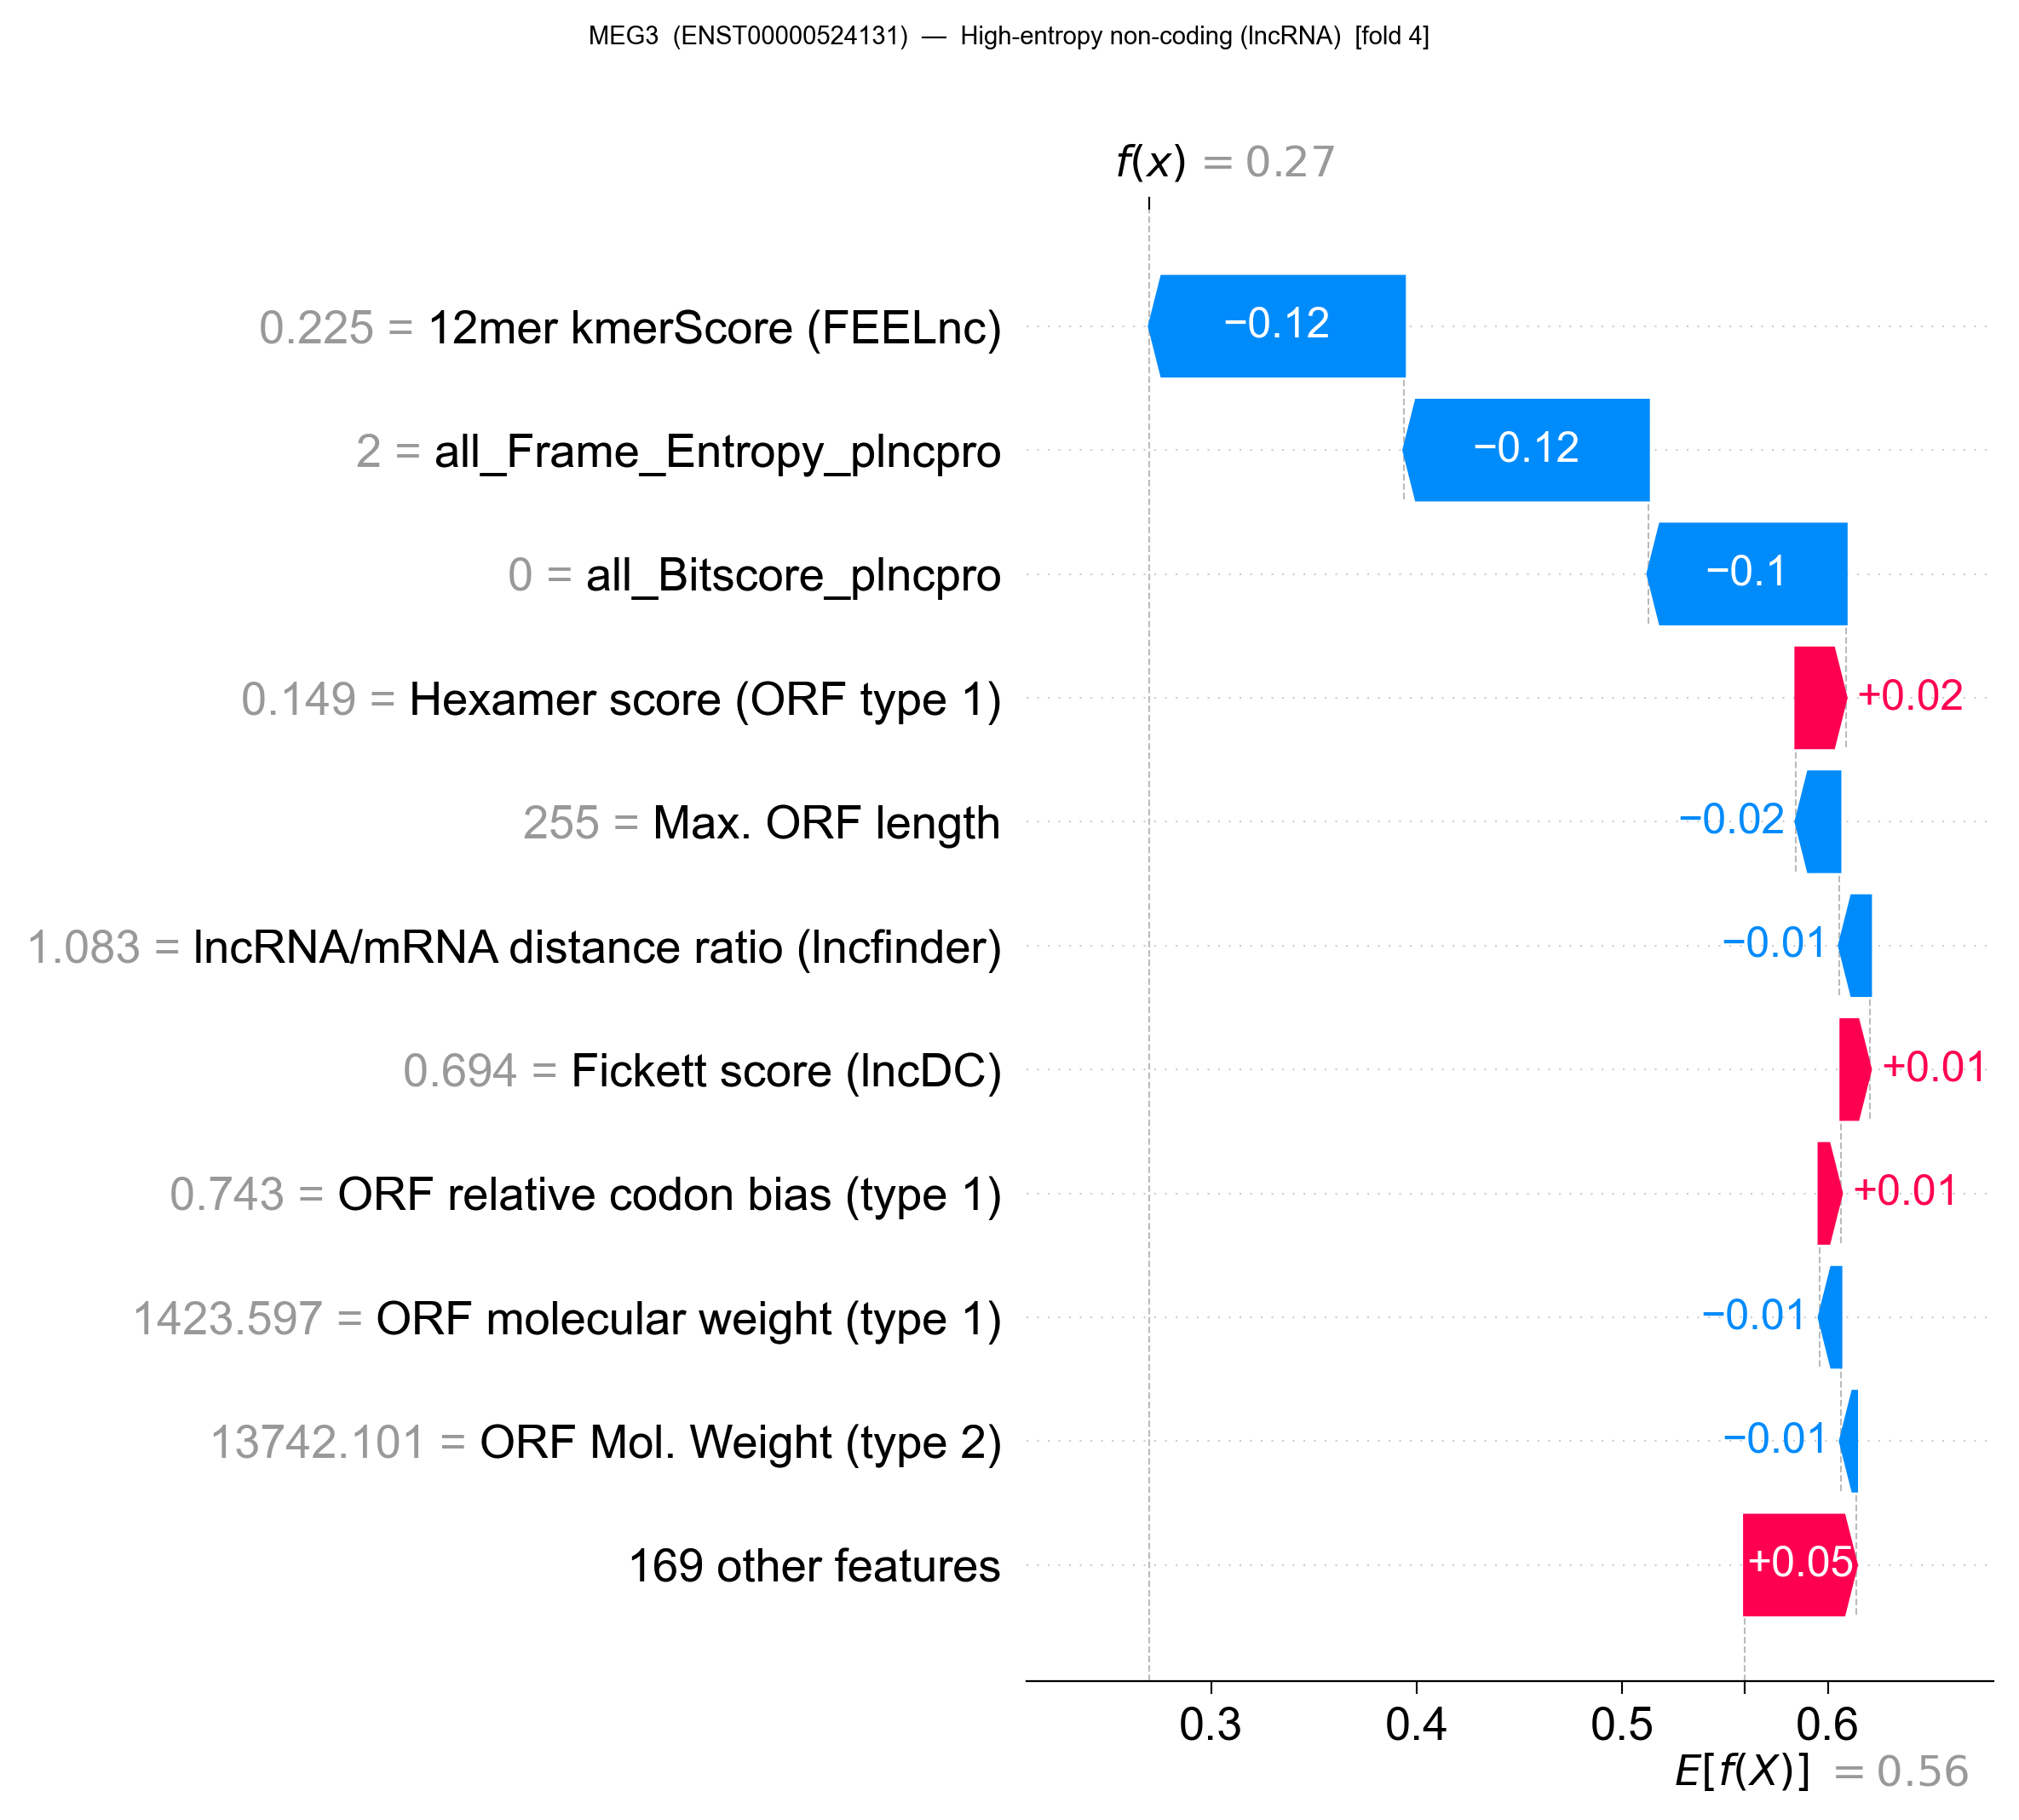

In [ ]:
# ── Waterfall plots (one per transcript, grouped) ─────────────────────────────
group_titles = {
    "low_entropy_coding":  "Low-entropy coding (mRNA)",
    "low_entropy_lncrna":  "Low-entropy non-coding (lncRNA)",
    "high_entropy_coding": "High-entropy coding (mRNA)",
    "high_entropy_lncrna": "High-entropy non-coding (lncRNA)",
}

for group, tids in cherry_pick.items():
    names = cherry_names[group]
    print(f"\n{'─'*60}")
    print(f"  {group_titles[group]}")
    print(f"{'─'*60}")

    for tid, gene_name in zip(tids, names):
        shap_s, fold_i, full_id = get_shap_row(tid, transcript_index, fold_data)
        if shap_s is None:
            print(f"  SKIP {tid} ({gene_name}) — not in any test fold")
            continue

        res = fold_data[fold_i]
        x_row = res["X_test"].loc[full_id]

        # Apply readable labels via feat_dict
        readable_feats = [feat_dict.get(f, f) for f in shap_s.index.tolist()]

        expl = shap.Explanation(
            values=shap_s.values,
            base_values=res["base_val"],
            data=x_row.values,
            feature_names=readable_feats,
        )

        fig = plt.figure(figsize=(WATERFALL_W_CM / 2.54, WATERFALL_H_CM / 2.54), dpi=WATERFALL_DPI)
        shap.plots.waterfall(expl, max_display=WATERFALL_MAX_DISPLAY, show=False)
        fig.suptitle(
            f"{gene_name}  ({tid})  —  {group_titles[group]}  [fold {fold_i}]",
            fontsize=7, y=1.01,
        )

        plt.tight_layout()

        maybe_save(fig, f"waterfall_{group}_{gene_name}_old")
        plt.show()
        plt.close(fig)

<Figure size 2400x2700 with 3 Axes>


────────────────────────────────────────────────────────────
  Low-entropy coding
────────────────────────────────────────────────────────────


  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_coding_EGF.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_coding_EGF.png


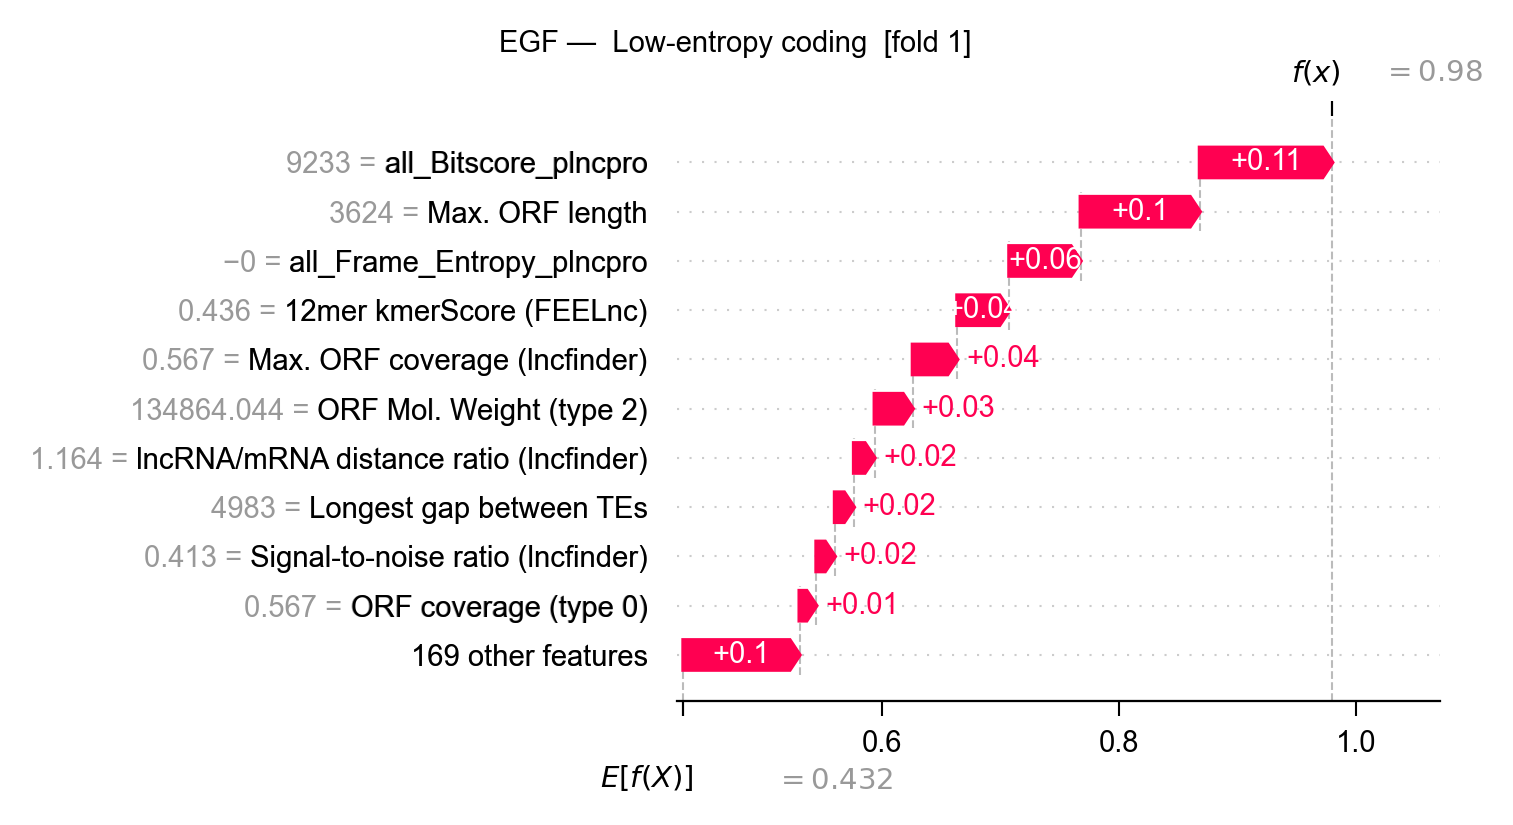


────────────────────────────────────────────────────────────
  Low-entropy lncRNA
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_lncrna_MALAT1.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_low_entropy_lncrna_MALAT1.png


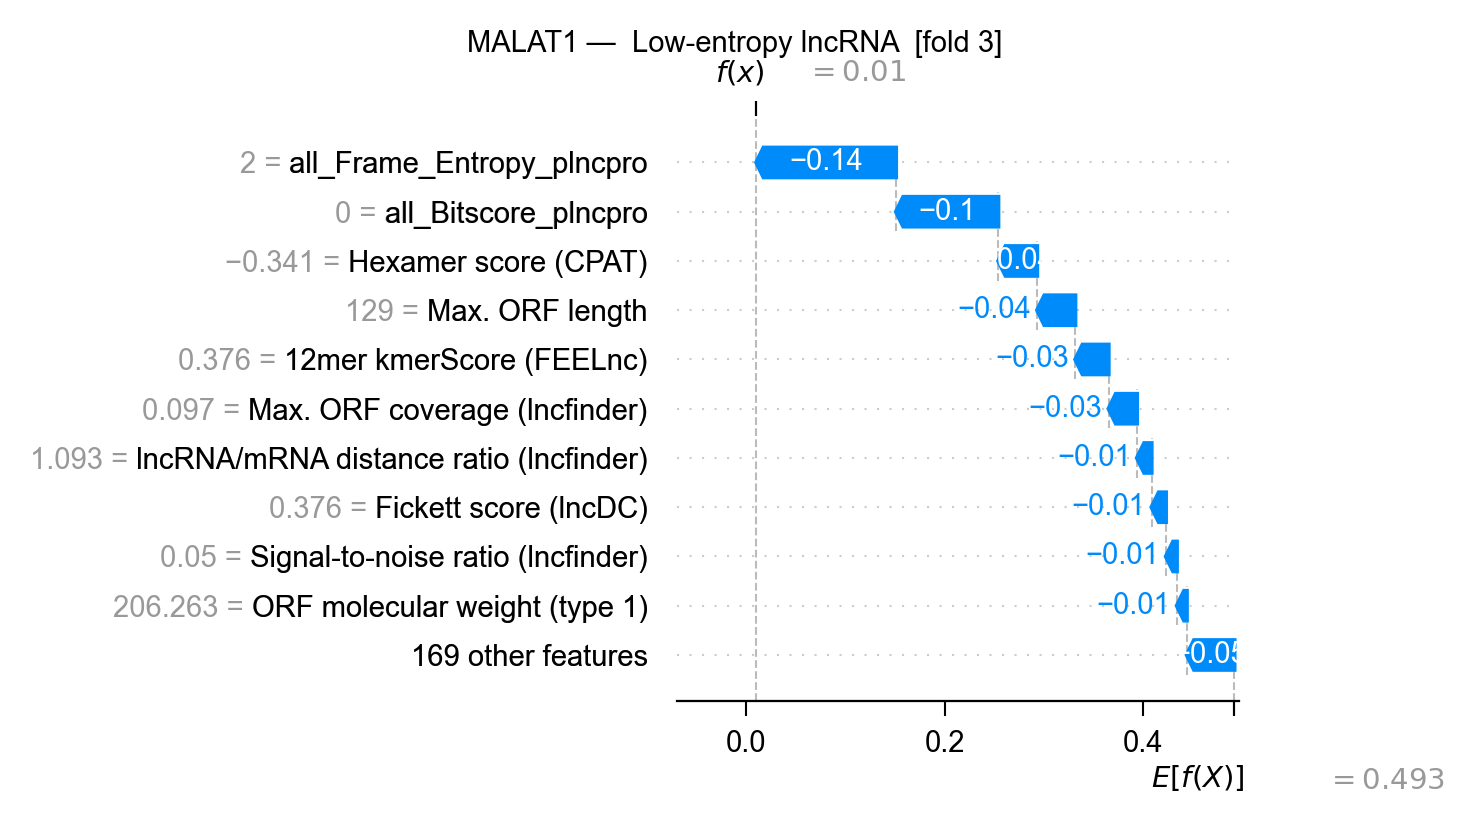


────────────────────────────────────────────────────────────
  High-entropy coding
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_coding_SWI5.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_coding_SWI5.png


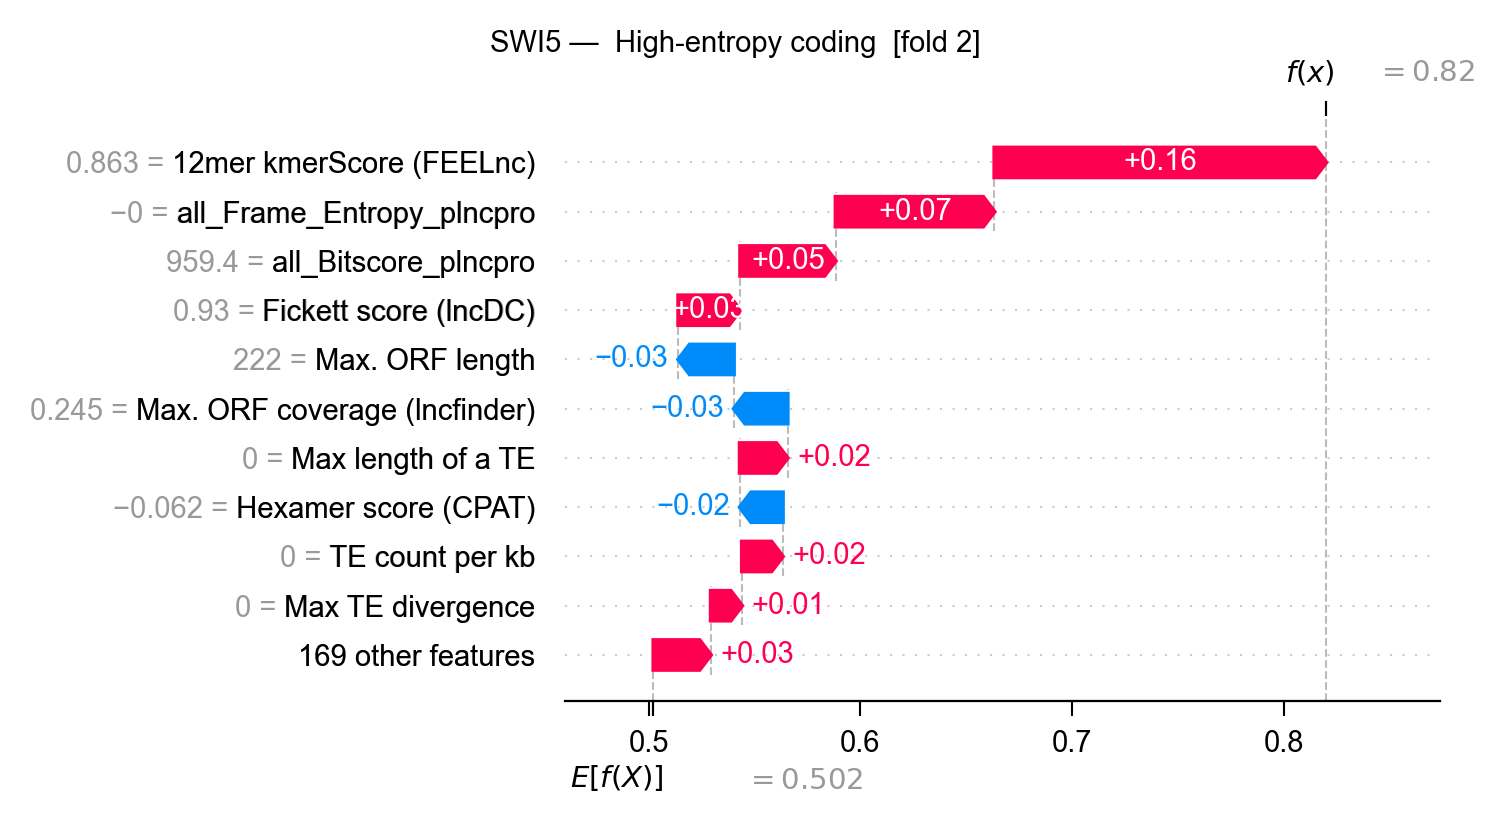


────────────────────────────────────────────────────────────
  High-entropy lncRNA
────────────────────────────────────────────────────────────
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_lncrna_MEG3.pdf
  Saved: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/shap_clustered/waterfall_high_entropy_lncrna_MEG3.png


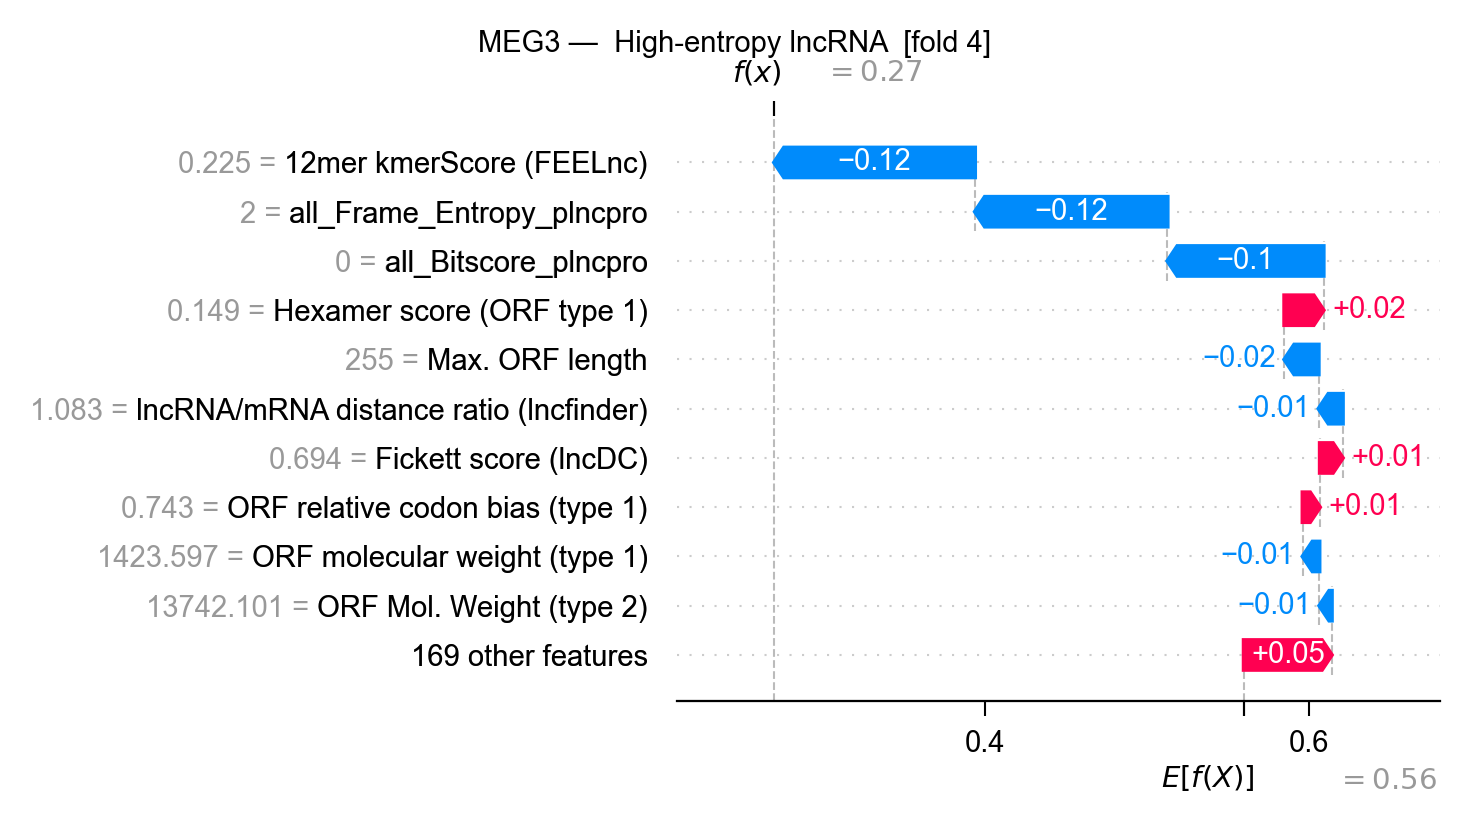

In [ ]:
# ── Waterfall plots (one per transcript, grouped) ─────────────────────────────
group_titles = {
    "low_entropy_coding":  "Low-entropy coding",
    "low_entropy_lncrna":  "Low-entropy lncRNA",
    "high_entropy_coding": "High-entropy coding",
    "high_entropy_lncrna": "High-entropy lncRNA",
}

for group, tids in cherry_pick.items():
    names = cherry_names[group]
    print(f"\n{'─'*60}")
    print(f"  {group_titles[group]}")
    print(f"{'─'*60}")

    for tid, gene_name in zip(tids, names):
        shap_s, fold_i, full_id = get_shap_row(tid, transcript_index, fold_data)
        if shap_s is None:
            print(f"  SKIP {tid} ({gene_name}) — not in any test fold")
            continue

        res = fold_data[fold_i]
        x_row = res["X_test"].loc[full_id]

        # Apply readable labels via feat_dict
        readable_feats = [feat_dict.get(f, f) for f in shap_s.index.tolist()]

        expl = shap.Explanation(
            values=shap_s.values,
            base_values=res["base_val"],
            data=x_row.values,
            feature_names=readable_feats,
        )

        #############################################################
        # Patch SHAP's waterfall plot to use our custom figure size
        #############################################################
        import matplotlib.pyplot as plt
        from unittest.mock import patch

        TARGET_BAR_WIDTH = 0.6   # default is 0.8 — reduce for thinner bars / more whitespace
        TARGET_ROW_HEIGHT = 0.3  # default is 0.5 — reduce for more compact rows

        _orig_arrow = plt.arrow
        _orig_figure = plt.gcf  # used to control figure height

        def _patched_arrow(*args, **kwargs):
            kwargs["width"] = TARGET_BAR_WIDTH
            kwargs["head_width"] = TARGET_BAR_WIDTH
            return _orig_arrow(*args, **kwargs)

        plt.arrow = _patched_arrow

        fig = plt.figure(figsize=(WATERFALL_W_CM / 2.54, WATERFALL_H_CM / 2.54), dpi=WATERFALL_DPI)
        shap.plots.waterfall(expl, max_display=WATERFALL_MAX_DISPLAY, show=False)
        fig.suptitle(
            f"{gene_name} —  {group_titles[group]}  [fold {fold_i}]",
            fontsize=7, y=0.9,
        )
        #({tid}) 

        plt.arrow = _orig_arrow  # restore immediately

        # Manually correct y-axis limits to match the new spacing
        ax = plt.gca()
        n = min(10, len(shap_s.values))
        #ax.set_ylim(-0.5, 20)

        plt.gcf().set_size_inches(5, n * TARGET_ROW_HEIGHT)

        # Edit hardcoded formatting

        # Walk every Text object across every axis in the figure
        for ax in fig.axes:
            # Tick labels (feature names, x-axis values)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontsize(7)
            # Free-floating text (bar value annotations)
            for txt in ax.texts:
                txt.set_fontsize(7)
            # Axis labels
            ax.xaxis.label.set_size(7)
            ax.yaxis.label.set_size(7)

        plt.tight_layout()

        maybe_save(fig, f"waterfall_{group}_{gene_name}")
        plt.show()
        plt.close(fig)

## Summary / conclusions

| Plot | Description | Save stem |
|------|-------------|-----------|
| 1 | Feature importance (mean ± std \|SHAP\|) | `shap_importance_mean_std` |
| 2 | Per-fold \|SHAP\| heatmap (features × folds) | `shap_fold_heatmap` |
| 3 | Beeswarm — all evaluated transcripts pooled | `beeswarm_all_transcripts` |
| 4 | RF predicted probability distribution by class | `prediction_probability_distribution` |
| 5 | Waterfall — 17 cherry-picked transcripts (4 groups) | `waterfall_{group}_{gene_name}` |

Set `SAVE_PLOTS = True` in the *Configuration* cell to write each plot as both `.pdf` (vector) and `.png` (300 dpi) into `FIGURES_DIR`.

**Cherry-pick groups**

| Group | Transcripts |
|-------|-------------|
| low_entropy_coding | EGF, PNMA2, AQP5, UPF1, COBLL1, AKT1, DICER1, BRCA2 |
| low_entropy_lncrna | XIST, MALAT1 |
| high_entropy_coding | MT-ND5, TGFBI, SWI5, TP53I13, AQP1 |
| high_entropy_lncrna | MEG3, CHASERR |

**Input files used**  
```
results/gencode.v47.common.cdhit.cv/features/shap_clustered/
    shap_aggregated.csv
    shap_per_fold_mean_abs.csv
    all_predictions.csv
    performance_summary.csv
    fold{1..5}/shap_values.csv, X_test.csv, y_pred.csv, base_val.txt
```